# GameTheory 04f — Théories de la décision face à un prédicteur : Newcomb, EDT, CDT, UDT et inattention rationnelle

**Navigation** : [<< 4e-Reflective-Oracles](GameTheory-04e-Reflective-Oracles.ipynb) | [Index](README.md)

> **Sources primaires** (archives privées, PDF hors Git) :
> - Wei Dai (2023). *UDT shows that decision theory is more puzzling than ever*. AI Alignment Forum, 13 septembre 2023. `G:\Mon Drive\MyIA\IA\Bibliographie IA\Probabilistic\2023 - Dai - UDT shows that decision theory is more puzzling than ever.pdf`
> - Mohajeri (2023). *Conditional causal decision theory reduces to evidential decision theory*. Analytic Philosophy, doi:10.1111/phib.12298. `G:\Mon Drive\MyIA\IA\Bibliographie IA\Probabilistic\2023 - Mohajeri - Conditional causal decision theory reduces to evidential decision theory.pdf`
> - Tong Mu, Stephan Zheng, Alexander Trott (2022). *Modeling Bounded Rationality in Multi-Agent Simulations Using Rationally Inattentive Reinforcement Learning*. arXiv:2202.01691. `G:\Mon Drive\MyIA\IA\Bibliographie IA\GameTheory\2022 - Mu Zheng Trott - Modeling Bounded Rationality in Multi-Agent Simulations.pdf`

Le notebook [04e](GameTheory-04e-Reflective-Oracles.ipynb) a montré, sur une chasse au cerf corrélée, que la décision causale (CDT) et la décision évidentielle (EDT) peuvent désigner des actions différentes. Ce notebook creuse cet écart. Il pose la même question à plusieurs théories de la décision : **que faut-il compter comme conséquence de mon choix, quand un autre agent ou la nature est corrélé à ce choix ?**

| Théorie | Ce qu'elle évalue | Formule |
|---|---|---|
| **EDT** (évidentielle) | l'acte comme un indice sur l'état du monde | $\mathbb{E}[U \mid A = a]$ |
| **CDT** (causale) | l'acte comme une intervention | $\mathbb{E}[U \mid \mathrm{do}(A = a)]$ |
| **CCDT** (Edgington 2011) | la probabilité que l'acte *cause* chaque conséquence | $\sum_i p((A \to C_i) \mid A)\, v(C_i)$ |
| **UDT / FDT** (sans mise à jour) | une *politique* choisie avant toute observation | $\max_\pi \mathbb{E}[U \mid \text{le monde réagit à } \pi]$ |
| **Inattention rationnelle** (Sims 2003) | le coût d'extraire l'information elle-même | $\max_{p(a \mid s)} \mathbb{E}[u] - \lambda\, I(s; a)$ |

**Objectifs** :

1. calculer exactement les seuils de décision du problème de Newcomb et de la lésion de Fisher, puis les recouper par simulation et par un modèle causal ajusté avec `dowhy` ;
2. reproduire l'argument de Mohajeri : la CCDT, appliquée à des conséquences complètement spécifiées, redonne les verdicts d'EDT ;
3. évaluer EDT, CDT et UDT sur six problèmes avec **un seul cadre générique**, sans coder les verdicts à la main ;
4. mettre en équations le problème 2TDT-1CDT de Wei Dai, qui montre que UDT ne clôt pas la question pour autant ;
5. résoudre un problème d'inattention rationnelle par l'algorithme de Blahut-Arimoto et vérifier ses conditions d'optimalité.

**Prérequis** : GT-02 (matrices de gains, dilemme du prisonnier), GT-04e (écart CDT/EDT), probabilités conditionnelles. La section 2 utilise l'opérateur `do` de Pearl.

**Durée estimée** : 75 min.

**Ce que ce notebook ne prétend pas faire** : trancher entre ces théories. Wei Dai, qui a proposé UDT, écrit en 2023 qu'aucun des problèmes ouverts de sa liste n'a de solution définitive et que la plupart restent « grands ouverts ». Chaque section calcule ce que chaque théorie recommande et ce que cette recommandation rapporte ; la section 7 dresse la liste de ce qui reste hors de portée.

## 0. Imports et constantes

Les calculs exacts utilisent `fractions.Fraction` : un seuil comme $1001/2000$ se vérifie alors par égalité, pas à une tolérance près. `dowhy.gcm` sert à ajuster un modèle causal sur des données simulées (section 2), `scipy.optimize` à contre-vérifier l'algorithme de Blahut-Arimoto (section 6). Toutes les graines sont fixées.

In [1]:
import itertools
import time
from dataclasses import dataclass
from fractions import Fraction as Fr
from typing import Callable

import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import minimize

import dowhy
from dowhy import gcm
from dowhy.gcm import config as gcm_config
from dowhy.gcm.util.general import set_random_seed

gcm_config.disable_progress_bars()
SEED = 0
set_random_seed(SEED)
pd.set_option("display.width", 160)

print(f"numpy {np.__version__} | scipy {scipy.__version__} | pandas {pd.__version__} | "
      f"matplotlib {matplotlib.__version__} | networkx {nx.__version__} | dowhy {dowhy.__version__}")

numpy 2.4.4 | scipy 1.17.1 | pandas 2.3.3 | matplotlib 3.10.8 | networkx 3.6.1 | dowhy 0.14


## 1. Le problème de Newcomb

Deux boîtes sont posées devant vous. La boîte transparente contient $K = 1\,000$ dollars. La boîte opaque contient $M = 1\,000\,000$ dollars **si et seulement si** un prédicteur a prévu, la veille, que vous prendriez la boîte opaque seule. Le prédicteur a raison avec une probabilité $p$. Vous choisissez entre la boîte opaque seule et les deux boîtes (Nozick 1969).

- **EDT** traite le choix comme un indice sur la prédiction. Prendre une boîte rend probable, à $p$, que la boîte opaque soit pleine :
  $\mathbb{E}[U \mid \text{1 boîte}] = pM$ et $\mathbb{E}[U \mid \text{2 boîtes}] = (1-p)M + K$.
  EDT prend une boîte si et seulement si $pM > (1-p)M + K$, soit $p > p^* = \dfrac{M + K}{2M}$.
- **CDT** remarque que le contenu est fixé avant le choix : le geste ne peut plus le modifier. Quelle que soit la crédence $b$ que la boîte soit pleine, prendre les deux boîtes rapporte exactement $K$ de plus. C'est un argument de **dominance**, indépendant de $b$.

La cellule suivante calcule $p^*$ en arithmétique exacte, vérifie la dominance CDT sur 101 crédences et trace les deux espérances d'EDT.

Seuil EDT : p* = (M + K) / (2M) = 1001/2000 = 0.5005
  au seuil, les deux actes valent exactement 500500 dollars
CDT : E[2 boîtes] - E[1 boîte] = 1000 dollars pour chacune des 101 crédences b de [0, 1]

     p   E[U | 1 boîte]  E[U | 2 boîtes]   choix EDT   choix CDT
0.5000         500,000          501,000     2 boîtes    2 boîtes
0.5005         500,500          500,500  indifférent    2 boîtes
0.5100         510,000          491,000      1 boîte    2 boîtes
0.6000         600,000          401,000      1 boîte    2 boîtes
0.9000         900,000          101,000      1 boîte    2 boîtes
0.9900         990,000           11,000      1 boîte    2 boîtes


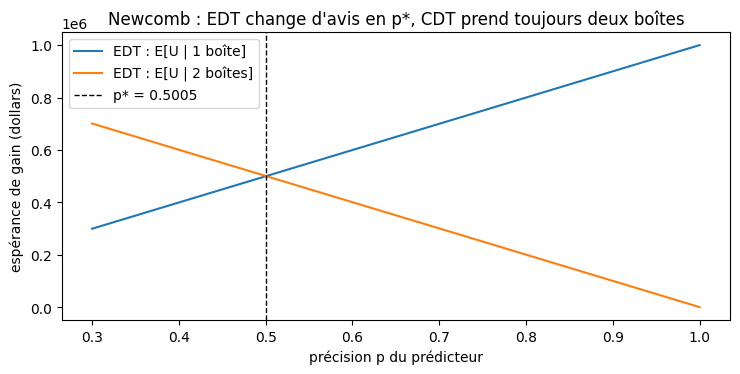

In [2]:
M, K = 1_000_000, 1_000   # boîte opaque, boîte transparente (dollars)


def edt_newcomb(p):
    # Le choix est un indice sur la prédiction, correcte avec probabilité p.
    return {"1 boîte": p * M, "2 boîtes": (1 - p) * M + K}


def cdt_newcomb(b):
    # Le contenu est fixé ; b = crédence que la boîte opaque soit pleine.
    return {"1 boîte": b * M, "2 boîtes": b * M + K}


p_star = Fr(M + K, 2 * M)
e_star = edt_newcomb(p_star)
assert e_star["1 boîte"] == e_star["2 boîtes"] == 500_500
print(f"Seuil EDT : p* = (M + K) / (2M) = {p_star} = {float(p_star)}")
print(f"  au seuil, les deux actes valent exactement {e_star['1 boîte']} dollars")

b_grille = np.linspace(0.0, 1.0, 101)
ecarts = np.array([cdt_newcomb(b)["2 boîtes"] - cdt_newcomb(b)["1 boîte"] for b in b_grille])
assert np.allclose(ecarts, K)
print(f"CDT : E[2 boîtes] - E[1 boîte] = {ecarts.min():.0f} dollars pour chacune des {len(b_grille)} crédences b de [0, 1]")

print("\n     p   E[U | 1 boîte]  E[U | 2 boîtes]   choix EDT   choix CDT")
for p in [0.5, 0.5005, 0.51, 0.6, 0.9, 0.99]:
    e = edt_newcomb(p)
    if abs(e["1 boîte"] - e["2 boîtes"]) < 1e-6:
        choix = "indifférent"
    else:
        choix = max(e, key=e.get)
    print(f"{p:6.4f}  {e['1 boîte']:14,.0f}  {e['2 boîtes']:15,.0f}  {choix:>11}    2 boîtes")

p_grille = np.linspace(0.3, 1.0, 400)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(p_grille, p_grille * M, label="EDT : E[U | 1 boîte]")
ax.plot(p_grille, (1 - p_grille) * M + K, label="EDT : E[U | 2 boîtes]")
ax.axvline(float(p_star), color="k", ls="--", lw=1, label=f"p* = {float(p_star)}")
ax.set_xlabel("précision p du prédicteur")
ax.set_ylabel("espérance de gain (dollars)")
ax.set_title("Newcomb : EDT change d'avis en p*, CDT prend toujours deux boîtes")
ax.legend()
plt.tight_layout()
plt.show()

### Lecture du résultat

- Le seuil vaut exactement $p^* = 1001/2000 = 0.5005$ : EDT prend une seule boîte dès que le prédicteur fait **à peine mieux que le hasard**. Le rapport $M/K = 1000$ explique ce seuil si bas : un point de précision en plus déplace $20\,000$ dollars d'écart entre les deux espérances, alors que la boîte transparente n'en offre que $1\,000$.
- Au seuil, les deux actes valent chacun $500\,500$ dollars ; à $p = 0.5$, EDT prend encore les deux boîtes, et dès $p = 0.51$ elle n'en prend plus qu'une.
- CDT prend les deux boîtes pour les 101 crédences testées, avec un écart constant de $1\,000$ dollars. La colonne « choix CDT » ne dépend pas de $p$ : pour CDT, la précision du prédicteur ne change que la crédence $b$, et l'argument de dominance ne dépend pas de $b$.

Les deux théories ne se disputent donc pas sur un calcul : elles partent du même modèle et ne posent pas la même question. EDT demande « quel choix est la meilleure nouvelle ? », CDT demande « quel choix produit le meilleur résultat, le monde étant ce qu'il est ? ».

### « Why ain'cha rich? » en simulation

L'argument classique en faveur d'une seule boîte (Lewis 1981 lui a donné ce nom pour le critiquer) est empirique : faites passer le test à beaucoup de monde, et ceux qui ne prennent qu'une boîte repartent plus riches. La cellule suivante simule 100 000 agents, moitié de chaque type, face à un prédicteur de précision $p$. Elle calcule aussi le **gain contrefactuel à contenu fixé** : ce qu'aurait obtenu chaque agent en changeant d'acte, la boîte opaque restant telle qu'elle a été remplie. C'est la quantité qui intéresse CDT.

In [3]:
rng = np.random.default_rng(SEED)
N_AGENTS = 100_000
lignes = []
for p in [0.5, 0.5005, 0.6, 0.9, 0.99]:
    un_boite = rng.random(N_AGENTS) < 0.5
    correct = rng.random(N_AGENTS) < p
    predit_un = np.where(correct, un_boite, ~un_boite)      # la prédiction remplit la boîte
    gain = np.where(predit_un, M, 0) + np.where(un_boite, 0, K)
    contrefactuel = np.where(un_boite, gain + K, gain - K)  # l'autre acte, contenu inchangé
    g1, g2 = gain[un_boite], gain[~un_boite]
    se1 = g1.std(ddof=1) / np.sqrt(len(g1))
    se2 = g2.std(ddof=1) / np.sqrt(len(g2))
    th = edt_newcomb(p)
    assert abs(g1.mean() - th["1 boîte"]) < 4 * se1
    assert abs(g2.mean() - th["2 boîtes"]) < 4 * se2
    lignes.append({
        "p": p,
        "moy. 1 boîte": g1.mean(),
        "moy. 2 boîtes": g2.mean(),
        "écart observé": g1.mean() - g2.mean(),
        "écart théorique": round(th["1 boîte"] - th["2 boîtes"], 6) + 0.0,  # évite un -0.0000 d'arrondi
        "erreur-type": np.hypot(se1, se2),
        "1 boîte -> 2 boîtes": (contrefactuel[un_boite] - gain[un_boite]).mean(),
    })
table_mc = pd.DataFrame(lignes)
print(table_mc.to_string(index=False, float_format=lambda x: f"{x:,.0f}" if abs(x) >= 10 else f"{x:.4f}"))

     p  moy. 1 boîte  moy. 2 boîtes  écart observé  écart théorique  erreur-type  1 boîte -> 2 boîtes
0.5000       503,314        499,317          3,997           -1,000        3,162                1,000
0.5005       498,932        501,892         -2,960           0.0000        3,162                1,000
0.6000       601,950        402,061        199,889          199,000        3,098                1,000
0.9000       901,571        102,825        798,746          799,000        1,898                1,000
0.9900       990,547         10,527        980,020          979,000          613                1,000


### Lecture du résultat

- Les moyennes simulées tombent à moins de quatre erreurs-types des espérances d'EDT pour les cinq précisions (les `assert` passent).
- À $p = 0.99$, les agents à une boîte gagnent en moyenne $990\,547$ dollars et les autres $10\,527$ : l'écart observé ($980\,020$) est à moins de deux erreurs-types ($613$) de l'écart théorique ($979\,000$). C'est le « why ain'cha rich? » : le groupe qui suit EDT est incontestablement plus riche.
- Près du seuil, la simulation ne tranche rien : à $p = 0.5$ et $p = 0.5005$, l'écart théorique ($-1\,000$ dollars, puis $0$) est noyé dans une erreur-type de $3\,162$. Les écarts observés ($+3\,997$, puis $-2\,960$) sont du même ordre que l'erreur-type, et le premier a même le signe opposé à la théorie. L'erreur-type décroît comme $1/\sqrt{N}$ : pour qu'un écart de $1\,000$ dollars dépasse quatre erreurs-types, il faudrait environ $16$ millions d'agents, soit $160$ fois cette simulation.
- La dernière colonne vaut $+1\,000$ pour toutes les précisions : **chaque** agent à une boîte aurait gagné $1\,000$ dollars de plus en prenant les deux, sa boîte opaque restant telle qu'elle était. C'est la réponse de CDT : les riches ont été récompensés pour leur *type*, que le prédicteur a lu, pas pour leur *geste*. Lewis résume : le jeu est truqué en faveur des irrationnels.

Les deux colonnes décrivent le même tirage. Elles répondent à deux questions différentes, et c'est exactement le désaccord entre EDT et CDT.

### Exercice 1 — Un prédicteur asymétrique

Supposons que le prédicteur reconnaisse mieux un type que l'autre : il prédit correctement un agent à une boîte avec probabilité $p_1$, un agent à deux boîtes avec probabilité $p_2$.

- **Étape 1** : écrire $\mathbb{E}[U \mid \text{1 boîte}]$ et $\mathbb{E}[U \mid \text{2 boîtes}]$ pour EDT en fonction de $p_1$, $p_2$, $M$ et $K$.
- **Étape 2** : en déduire la frontière dans le plan $(p_1, p_2)$ au-delà de laquelle EDT prend une seule boîte, et la tracer sur $[0.4, 1]^2$.
- **Étape 3** : vérifier que l'on retrouve $p^* = 0.5005$ sur la diagonale $p_1 = p_2$. Un prédicteur qui ne se trompe jamais sur les agents à deux boîtes ($p_2 = 1$) suffit-il à faire prendre une boîte à EDT quel que soit $p_1$ ?

*Indice* : seule la probabilité que la boîte opaque soit pleine **sachant l'acte** entre dans le calcul d'EDT. Et CDT change-t-elle d'avis ?

In [4]:
# Exercice 1 : frontière EDT pour un prédicteur asymétrique.
# TODO étudiant : écrire les deux espérances en fonction de (p1, p2),
# puis tracer la frontière sur une grille de [0.4, 1]^2.

esperances_asymetriques = None  # TODO étudiant : fonction (p1, p2) -> dict des deux espérances
frontiere = None  # TODO étudiant : p2 en fonction de p1 sur la frontière

print("Exercice 1 à compléter : frontière EDT d'un prédicteur asymétrique.")

Exercice 1 à compléter : frontière EDT d'un prédicteur asymétrique.


## 2. La lésion de Fisher : quand EDT se trompe

Newcomb semble donner raison à EDT. Le cas imaginé par Fisher (1958) pour défendre le tabac va dans l'autre sens. Supposons qu'un gène $G$ provoque à la fois l'envie de fumer et le cancer, et que fumer ne cause **rien** d'autre que du plaisir. Fumer reste corrélé au cancer, mais arrêter ne protège de rien.

Les valeurs sont celles du tableau 1 de Mohajeri (2023), reprises d'Edgington (2011) :

| | vie courte (cancer) | vie longue |
|---|---|---|
| **fumer** (plaisir) | 1 | 11 |
| **arrêter** (sans plaisir) | 0 | 10 |

Fumer ajoute toujours 1 : c'est la dominance, cette fois du côté de l'intuition. Le modèle causal structurel (SCM) choisi ici reproduit les corrélations de l'article, $P(\text{cancer} \mid \text{fumer}) = 0.6$ et $P(\text{cancer} \mid \text{arrêter}) = 0.2$ :

$$G \sim \mathcal{B}(2/5), \qquad P(S = 1 \mid G = 1) = 3/4, \quad P(S = 1 \mid G = 0) = 1/3, \qquad C = G .$$

Le cancer $C$ ne dépend que du gène. La cellule calcule en fractions exactes ce que valent les deux actes pour EDT, qui conditionne sur l'acte, et pour CDT, qui intervient avec $\mathrm{do}(S = s)$ et laisse donc $G$ à sa loi a priori.

In [5]:
PG = Fr(2, 5)                               # P(G = 1)
PS_G = {1: Fr(3, 4), 0: Fr(1, 3)}           # P(fumer | G)
VAL_FISHER = {("S", 1): 1, ("S", 0): 11, ("Q", 1): 0, ("Q", 0): 10}   # (acte, cancer) -> valeur

p_fumer = PG * PS_G[1] + (1 - PG) * PS_G[0]
p_c_S = PG * PS_G[1] / p_fumer                     # P(cancer | fumer)
p_c_Q = PG * (1 - PS_G[1]) / (1 - p_fumer)         # P(cancer | arrêter)


def valeur(acte, p_cancer):
    return p_cancer * VAL_FISHER[(acte, 1)] + (1 - p_cancer) * VAL_FISHER[(acte, 0)]


edt_fisher = {"fumer": valeur("S", p_c_S), "arrêter": valeur("Q", p_c_Q)}
cdt_fisher = {"fumer": valeur("S", PG), "arrêter": valeur("Q", PG)}   # do(S) : G garde sa loi a priori

assert (p_fumer, p_c_S, p_c_Q) == (Fr(1, 2), Fr(3, 5), Fr(1, 5))
assert edt_fisher == {"fumer": 5, "arrêter": 8}
assert cdt_fisher == {"fumer": 7, "arrêter": 6}
print(f"P(fumer) = {p_fumer}   P(cancer | fumer) = {p_c_S}   P(cancer | arrêter) = {p_c_Q}   P(cancer | do(.)) = {PG}")
print(f"EDT : fumer {edt_fisher['fumer']}, arrêter {edt_fisher['arrêter']}  -> {max(edt_fisher, key=edt_fisher.get)}")
print(f"CDT : fumer {cdt_fisher['fumer']}, arrêter {cdt_fisher['arrêter']}  -> {max(cdt_fisher, key=cdt_fisher.get)}")

P(fumer) = 1/2   P(cancer | fumer) = 3/5   P(cancer | arrêter) = 1/5   P(cancer | do(.)) = 2/5
EDT : fumer 5, arrêter 8  -> arrêter
CDT : fumer 7, arrêter 6  -> fumer


### Lecture du résultat

- Le modèle reproduit exactement les deux corrélations de l'article : $P(\text{cancer} \mid \text{fumer}) = 3/5$ et $P(\text{cancer} \mid \text{arrêter}) = 1/5$, pour une proportion de fumeurs de $1/2$.
- **EDT recommande d'arrêter** ($8 > 5$). Arrêter est une bonne nouvelle : c'est un indice que l'on n'a pas le gène. Mais la décision ne change pas le gène.
- **CDT recommande de fumer** ($7 > 6$). Sous $\mathrm{do}(S)$, le risque de cancer reste $2/5$ quel que soit l'acte, et fumer ajoute exactement 1.

Newcomb et Fisher ont la même structure : un facteur caché, fixé avant la décision, corrélé à l'acte. Pourtant l'intuition commune prend une boîte dans Newcomb et fume dans Fisher. Aucune des deux théories classiques ne suit l'intuition sur les deux problèmes à la fois : c'est l'observation qui motive la section 4.

### Recoupement par un modèle causal ajusté (`dowhy.gcm`)

Le calcul exact suppose le modèle connu. La cellule suivante part au contraire de **données** : 20 000 individus tirés du SCM, avec les colonnes $G$, $S$ et $C$. `dowhy.gcm` ajuste un mécanisme par nœud sur le graphe $G \to S$, $G \to C$, puis simule l'intervention $\mathrm{do}(S = s)$.

Pour montrer que le verdict vient du graphe et non des données, on ajuste aussi un **graphe naïf** $S \to C$ sur les mêmes lignes, sans la colonne $G$ : c'est ce que ferait un analyste qui croit que fumer cause le cancer.

In [6]:
t0 = time.time()
rng = np.random.default_rng(SEED)
N_OBS = 20_000
g = (rng.random(N_OBS) < float(PG)).astype(int)
s = (rng.random(N_OBS) < np.where(g == 1, 0.75, 1 / 3)).astype(int)
c = g.copy()
donnees = pd.DataFrame({"G": g.astype(str), "S": s.astype(str), "C": c.astype(str)})


def p_cancer_do(scm, s_val, n=N_OBS):
    echantillon = gcm.interventional_samples(scm, {"S": lambda x: s_val}, num_samples_to_draw=n)
    return float((echantillon["C"] == "1").mean())


set_random_seed(SEED)
scm_fisher = gcm.StructuralCausalModel(nx.DiGraph([("G", "S"), ("G", "C")]))
gcm.auto.assign_causal_mechanisms(scm_fisher, donnees)
gcm.fit(scm_fisher, donnees)
scm_naif = gcm.StructuralCausalModel(nx.DiGraph([("S", "C")]))
gcm.auto.assign_causal_mechanisms(scm_naif, donnees[["S", "C"]])
gcm.fit(scm_naif, donnees[["S", "C"]])

obs = {v: float((donnees.C[donnees.S == v] == "1").mean()) for v in ("1", "0")}
do_fisher = {v: p_cancer_do(scm_fisher, v) for v in ("1", "0")}
do_naif = {v: p_cancer_do(scm_naif, v) for v in ("1", "0")}

resume = pd.DataFrame({
    "P(cancer | S=s) observé": obs,
    "P(cancer | do(S=s)), graphe G->S, G->C": do_fisher,
    "P(cancer | do(S=s)), graphe naïf S->C": do_naif,
}).rename(index={"1": "fumer", "0": "arrêter"})
print(resume.round(4).to_string())
cdt_estime = {"fumer": valeur("S", do_fisher["1"]), "arrêter": valeur("Q", do_fisher["0"])}
cdt_naif = {"fumer": valeur("S", do_naif["1"]), "arrêter": valeur("Q", do_naif["0"])}
print(f"\nCDT sur le bon graphe : fumer {cdt_estime['fumer']:.3f}, arrêter {cdt_estime['arrêter']:.3f}")
print(f"CDT sur le graphe naïf : fumer {cdt_naif['fumer']:.3f}, arrêter {cdt_naif['arrêter']:.3f}")

assert abs(obs["1"] - 0.6) < 0.02 and abs(obs["0"] - 0.2) < 0.02
assert all(abs(v - 0.4) < 0.02 for v in do_fisher.values())
assert abs(do_naif["1"] - 0.6) < 0.02 and abs(do_naif["0"] - 0.2) < 0.02
assert cdt_estime["fumer"] > cdt_estime["arrêter"] and cdt_naif["fumer"] < cdt_naif["arrêter"]
print(f"mécanismes : {', '.join(f'{n}: {type(scm_fisher.causal_mechanism(n)).__name__}' for n in ('G', 'S', 'C'))}"
      f"   ({time.time() - t0:.1f} s)")

         P(cancer | S=s) observé  P(cancer | do(S=s)), graphe G->S, G->C  P(cancer | do(S=s)), graphe naïf S->C
fumer                     0.5945                                  0.3906                                 0.5960
arrêter                   0.1941                                  0.3968                                 0.1945

CDT sur le bon graphe : fumer 7.094, arrêter 6.032
CDT sur le graphe naïf : fumer 5.040, arrêter 8.055
mécanismes : G: EmpiricalDistribution, S: ClassifierFCM, C: ClassifierFCM   (11.8 s)


### Lecture du résultat

- Sur les données, $P(\text{cancer} \mid \text{fumer})$ et $P(\text{cancer} \mid \text{arrêter})$ retrouvent $0.6$ et $0.2$ à la précision d'échantillonnage.
- Avec le bon graphe, l'intervention $\mathrm{do}(S = s)$ ramène le risque à environ $0.4$ pour les deux actes, c'est-à-dire à $P(G = 1)$ : le modèle ajusté a appris que $S$ n'a pas d'arête vers $C$. Les valeurs CDT estimées sont proches de $7$ et $6$, et CDT fume.
- Avec le graphe naïf, les **mêmes lignes** donnent $\mathrm{do}(S = s) \approx P(\text{cancer} \mid S = s)$ : sans variable de confusion dans le graphe, l'intervention se confond avec le conditionnement, et « CDT » recommande d'arrêter comme EDT.

Aucune quantité calculée sur les données seules ne sépare les deux lectures. La différence entre EDT et CDT n'est pas une question d'estimation : c'est une hypothèse causale, que l'agent doit apporter.

### La défense par le chatouillement (Eells 1982)

Les défenseurs d'EDT répondent qu'un agent réel **sent** son envie de fumer avant de décider. Si le gène n'agit sur le choix qu'à travers cette envie $U$, alors, une fois l'envie observée, l'acte n'apporte plus aucune information sur le gène : $U$ fait écran entre $S$ et $G$.

On raffine le SCM en $G \to U \to S$, avec $P(U = 1 \mid G = 1) = 9/10$ et $P(U = 1 \mid G = 0) = 1/5$. Les probabilités $P(S \mid U)$ sont choisies pour que la loi de $S$ sachant $G$ reste exactement celle du modèle précédent : un agent qui n'écoute pas son envie voit donc les mêmes corrélations qu'avant.

In [7]:
PU_G = {1: Fr(9, 10), 0: Fr(1, 5)}          # P(envie | G)
PS_U = {1: Fr(17, 21), 0: Fr(3, 14)}        # P(fumer | envie)
for gv in (0, 1):
    assert PU_G[gv] * PS_U[1] + (1 - PU_G[gv]) * PS_U[0] == PS_G[gv]   # même loi de S sachant G


def p_g1_sachant(u=None, s=None):
    # P(G = 1 | U = u, S = s) par énumération exacte ; None = non observé.
    num = den = Fr(0)
    for gv, pg in ((1, PG), (0, 1 - PG)):
        for uv in (0, 1):
            pu = PU_G[gv] if uv == 1 else 1 - PU_G[gv]
            for sv in (0, 1):
                ps = PS_U[uv] if sv == 1 else 1 - PS_U[uv]
                if (u is None or uv == u) and (s is None or sv == s):
                    w = pg * pu * ps
                    den += w
                    num += w * (gv == 1)
    return num / den


assert p_g1_sachant(s=1) == Fr(3, 5) and p_g1_sachant(s=0) == Fr(1, 5)
lignes = []
for u in (1, 0):
    e_S = valeur("S", p_g1_sachant(u=u, s=1))
    e_Q = valeur("Q", p_g1_sachant(u=u, s=0))
    c_S, c_Q = valeur("S", p_g1_sachant(u=u)), valeur("Q", p_g1_sachant(u=u))
    assert (e_S, e_Q) == (c_S, c_Q) and e_S - e_Q == 1
    lignes.append({"envie": u, "P(G=1 | envie)": str(p_g1_sachant(u=u)),
                   "EDT fumer": str(e_S), "EDT arrêter": str(e_Q),
                   "CDT fumer": str(c_S), "CDT arrêter": str(c_Q)})
print(pd.DataFrame(lignes).to_string(index=False))
p_u1 = PG * PU_G[1] + (1 - PG) * PU_G[0]
gain_fumeur_informe = p_u1 * valeur("S", p_g1_sachant(u=1)) + (1 - p_u1) * valeur("S", p_g1_sachant(u=0))
print(f"\nSans observer l'envie : EDT fumer {valeur('S', p_g1_sachant(s=1))}, arrêter {valeur('Q', p_g1_sachant(s=0))}")
print(f"Agent qui observe son envie puis fume : gain espéré {gain_fumeur_informe}")

 envie P(G=1 | envie) EDT fumer EDT arrêter CDT fumer CDT arrêter
     1            3/4       7/2         5/2       7/2         5/2
     0           1/13    133/13      120/13    133/13      120/13

Sans observer l'envie : EDT fumer 5, arrêter 8
Agent qui observe son envie puis fume : gain espéré 7


### Lecture du résultat

- Sans observer l'envie, EDT retrouve $5$ contre $8$ et arrête : le modèle raffiné contient bien les mêmes corrélations.
- Une fois l'envie observée, $P(G = 1 \mid U, S) = P(G = 1 \mid U)$ : l'acte ne dit plus rien du gène. EDT et CDT calculent alors **les mêmes nombres** ($7/2$ contre $5/2$ avec l'envie, $133/13$ contre $120/13$ sans), et fumer gagne toujours d'exactement 1.
- Un agent qui observe son envie puis fume obtient en moyenne $7$, la valeur de CDT.

La défense marche, mais elle a un prix : elle suppose que tout ce par quoi le facteur caché agit sur le choix est **visible par l'agent** avant qu'il décide. Dans Newcomb, le prédicteur lit justement ce que l'agent ne peut pas observer de lui-même : son algorithme de décision. La section 4 pose la question à ce niveau-là.

## 3. La CCDT d'Edgington se ramène à EDT (Mohajeri 2023)

Edgington (2011) propose une voie médiane, la décision causale conditionnelle (CCDT). La valeur d'un acte y pondère chaque conséquence $C_i$ par la probabilité, **conditionnelle à l'acte**, que l'acte *cause* cette conséquence :

$$\mathrm{exv}_{\mathrm{CCDT}}(A) = \sum_i p\big((A \to C_i) \mid A\big)\, v(C_i).$$

L'idée est de garder le conditionnement d'EDT tout en ne comptant que ce que l'acte produit. Edgington affirme que la CCDT fume dans le cas de Fisher. Mohajeri montre que ce n'est pas le cas, et plus généralement qu'elle rend **toujours** les verdicts d'EDT. Son argument tient en une remarque : une conséquence complètement spécifiée contient l'acte lui-même. « Vie courte **avec** le plaisir de fumer » n'arrive que si l'on fume ; quand elle arrive, fumer y est donc pour quelque chose, et $p((S \to C_i) \mid S) = p(C_i \mid S)$.

Pour le vérifier sans le postuler, la cellule suivante code la relation « $A \to C$ » par la **dépendance contrefactuelle** : dans un monde $w$, l'acte $A$ cause $C$ si $C$ se produit sous $A$ et ne se produirait pas sous l'autre acte, $w$ restant fixé. On applique ce test à deux descriptions des conséquences :

- **fine** : (durée de vie, plaisir), comme dans le tableau de Mohajeri ;
- **grossière** : la durée de vie seule.

Le même évaluateur est ensuite appliqué au problème de Newcomb, avec des conséquences (contenu de la boîte opaque, boîtes prises).

In [8]:
def ccdt(probleme, acte, grain):
    # exv(A) = somme_i p((A -> C_i) | A) v(C_i), avec A -> C par dépendance contrefactuelle.
    autre = [a for a in probleme["actes"] if a != acte][0]
    poids = {}
    for w, pw in probleme["posterieur"](acte).items():
        c = grain(probleme["resultat"](w, acte))
        cause = grain(probleme["resultat"](w, autre)) != c
        poids[c] = poids.get(c, Fr(0)) + (pw if cause else Fr(0))
    valeurs = {c: probleme["valeur"](c) for c in poids}
    return sum(poids[c] * valeurs[c] for c in poids), poids


def edt_exact(probleme, acte):
    return sum(pw * probleme["valeur"](probleme["resultat"](w, acte))
               for w, pw in probleme["posterieur"](acte).items())


FISHER = {
    "actes": ["fumer", "arrêter"],
    "posterieur": lambda a: {1: p_c_S, 0: 1 - p_c_S} if a == "fumer" else {1: p_c_Q, 0: 1 - p_c_Q},
    "resultat": lambda gv, a: ("courte" if gv else "longue", "plaisir" if a == "fumer" else "sans"),
    "valeur": lambda c: {("courte", "plaisir"): 1, ("longue", "plaisir"): 11,
                         ("courte", "sans"): 0, ("longue", "sans"): 10}.get(c, 0),
}
PREC = Fr(99, 100)
NEWCOMB = {
    "actes": ["1 boîte", "2 boîtes"],
    "posterieur": lambda a: {"pleine": PREC, "vide": 1 - PREC} if a == "1 boîte" else {"pleine": 1 - PREC, "vide": PREC},
    "resultat": lambda w, a: (w, a),
    "valeur": lambda c: (1000 if c[0] == "pleine" else 0) + (1 if c[1] == "2 boîtes" else 0),
}
fine = lambda r: r
grossiere = lambda r: r[0]

for nom, pb in (("Fisher", FISHER), ("Newcomb (p = 0.99, en milliers)", NEWCOMB)):
    print(nom)
    for acte in pb["actes"]:
        v_fin, poids_fin = ccdt(pb, acte, fine)
        v_gros, poids_gros = ccdt(pb, acte, grossiere)
        assert v_fin == edt_exact(pb, acte)
        assert sum(poids_fin.values()) == 1 and sum(poids_gros.values()) == 0
        detail = ", ".join(f"{c}: {p}" for c, p in poids_fin.items())
        print(f"  {acte:9s} fine : CCDT = {str(v_fin):>9s} = EDT   poids {{{detail}}}")
        print(f"  {'':9s} grossière : somme des poids = {sum(poids_gros.values())}, CCDT = {v_gros}")

Fisher
  fumer     fine : CCDT =         5 = EDT   poids {('courte', 'plaisir'): 3/5, ('longue', 'plaisir'): 2/5}
            grossière : somme des poids = 0, CCDT = 0
  arrêter   fine : CCDT =         8 = EDT   poids {('courte', 'sans'): 1/5, ('longue', 'sans'): 4/5}
            grossière : somme des poids = 0, CCDT = 0
Newcomb (p = 0.99, en milliers)
  1 boîte   fine : CCDT =       990 = EDT   poids {('pleine', '1 boîte'): 99/100, ('vide', '1 boîte'): 1/100}
            grossière : somme des poids = 0, CCDT = 0
  2 boîtes  fine : CCDT =        11 = EDT   poids {('pleine', '2 boîtes'): 1/100, ('vide', '2 boîtes'): 99/100}
            grossière : somme des poids = 0, CCDT = 0


### Lecture du résultat

- **Description fine** : les poids de la CCDT valent exactement $P(C_i \mid A)$ ($3/5$ et $2/5$ pour fumer, $1/5$ et $4/5$ pour arrêter). La CCDT vaut donc $5$ pour fumer et $8$ pour arrêter, **égale à EDT à la fraction près**, et recommande d'arrêter. Sur Newcomb, elle prend une seule boîte ($990$ contre $11$ milliers de dollars), comme EDT. C'est l'équation (8)-(9) de Mohajeri, obtenue ici par le test contrefactuel et non posée à la main.
- **Description grossière** : la durée de vie ne dépend jamais de l'acte, donc aucune conséquence n'est « causée » par l'acte. Tous les poids sont nuls, leur somme vaut $0$ et la formule rend $0$ pour chaque acte : la CCDT ne dit plus rien. Pour Newcomb, le contenu de la boîte opaque ne dépend pas non plus du geste, et l'on retombe sur le même vide.

Autrement dit, la CCDT n'a que deux régimes : conséquences assez fines pour contenir l'acte, et elle coïncide avec EDT ; conséquences trop grossières, et elle n'est pas définie. Aucun des deux ne produit le verdict causaliste.

### D'où venait le « fumer » d'Edgington ?

Edgington obtient $11$ contre $0$ en pondérant chaque acte par la relation causale entre l'acte et **une composante** de la conséquence (la durée de vie), puis en attribuant la valeur de la conséquence complète. Avec $p((A \to x) \mid A) = 0$ pour toute composante $x$ de durée de vie, sa formule devient

$$\mathrm{exv}_{A \to x}(A) = p((A \to x) \mid A)\, v(x \,\&\, j_A) + \big(1 - p((A \to x) \mid A)\big)\, v(\bar{x} \,\&\, j_A) = v(\bar{x} \,\&\, j_A),$$

où $j_A$ est la composante « plaisir » propre à l'acte. Mohajeri remarque que le résultat dépend de la composante $x$ choisie : ses équations (14) et (16), et sa note 7 pour l'acte « arrêter ». La cellule énumère les quatre choix possibles.

In [9]:
def edgington(acte, composante):
    # Edgington (2011) : poids p((A -> x) | A) = 0 sur une composante de durée de vie.
    plaisir = "plaisir" if acte == "fumer" else "sans"
    autre_vie = "longue" if composante == "courte" else "courte"
    poids_x = Fr(0)   # la durée de vie ne dépend pas de l'acte
    return (poids_x * FISHER["valeur"]((composante, plaisir))
            + (1 - poids_x) * FISHER["valeur"]((autre_vie, plaisir)))


CHOIX = [("courte", "longue", "Edgington, éq. (10)-(11)"),
         ("longue", "longue", "Mohajeri, éq. (16)"),
         ("courte", "courte", "Mohajeri, note 7"),
         ("longue", "courte", "éq. (16) et note 7")]
lignes = []
for x_fumer, x_arreter, source in CHOIX:
    v_s, v_q = edgington("fumer", x_fumer), edgington("arrêter", x_arreter)
    lignes.append({"source": source, "composante pour fumer": x_fumer, "composante pour arrêter": x_arreter,
                   "exv(fumer)": int(v_s), "exv(arrêter)": int(v_q),
                   "verdict": "fumer" if v_s > v_q else "arrêter"})
table_edg = pd.DataFrame(lignes)
print(table_edg.to_string(index=False))
assert table_edg[["exv(fumer)", "exv(arrêter)"]].values.tolist() == [[11, 0], [1, 0], [11, 10], [1, 10]]
assert table_edg["verdict"].tolist() == ["fumer", "fumer", "fumer", "arrêter"]

                  source composante pour fumer composante pour arrêter  exv(fumer)  exv(arrêter) verdict
Edgington, éq. (10)-(11)                courte                  longue          11             0   fumer
      Mohajeri, éq. (16)                longue                  longue           1             0   fumer
        Mohajeri, note 7                courte                  courte          11            10   fumer
      éq. (16) et note 7                longue                  courte           1            10 arrêter


### Lecture du résultat

- La première ligne est le calcul d'Edgington, équations (10) et (11) de Mohajeri : composante « vie courte » pour fumer, « vie longue » pour arrêter, d'où $11$ contre $0$ et le verdict « fumer ».
- Choisir « vie longue » pour fumer (équation 16) fait tomber fumer à $1$ ; choisir « vie courte » pour arrêter (note 7) fait monter arrêter à $10$. Chaque changement isolé laisse le verdict à « fumer », mais les deux ensemble donnent $1$ contre $10$ et le verdict « arrêter », comme le note Mohajeri.

Le verdict dépend donc d'un choix de composante que la théorie ne fixe pas. En réalité, la formule n'évalue même plus la relation causale : elle rend la valeur de la conséquence **opposée** à la composante choisie. Ajoutée au calcul contrefactuel de la cellule précédente, c'est la conclusion de Mohajeri : bien appliquée, la CCDT est EDT ; appliquée comme Edgington, elle n'est pas une théorie bien définie.

## 4. UDT : choisir une politique plutôt qu'un acte

Les sections 1 et 2 laissent un malaise : EDT prend une boîte et arrête de fumer, CDT fume et prend deux boîtes, alors que l'intuition courante prend une boîte **et** fume. La théorie de la décision sans mise à jour (UDT, Wei Dai 2009), et sa variante FDT (Yudkowsky et Soares 2017), déplacent la question. L'agent ne choisit plus un acte après avoir observé le monde : il choisit **une politique** $\pi$, qui associe une action à chaque observation possible, et l'évalue **avant** toute observation.

La corrélation qui compte n'est plus la même :

- un prédicteur qui **calcule la politique** de l'agent (Newcomb, jumeau) réagit au choix de politique : UDT en tient compte, comme EDT ;
- un gène qui **cause** à la fois l'envie et le cancer (Fisher) ne dépend pas de la politique choisie : UDT l'ignore, comme CDT.

Le cadre générique ci-dessous formalise un problème par cinq ingrédients : les **aléas de la nature** et leur loi ; une loi a priori jointe sur (aléa, type d'agent), qui porte les corrélations de cause commune ; une **variable cachée** $h$ fixée avant la décision, qui peut dépendre de la politique à travers un prédicteur ; ce que l'agent **observe** ; et le **gain**. Les trois théories en découlent sans rien coder à la main :

- **EDT** au point $o$ : $\mathbb{E}[U \mid o,\ \pi(o) = a]$, en conditionnant sur le type d'agent ;
- **CDT** au point $o$ : la variable cachée est fixée ; la crédence $P(\text{aléa}, h \mid o)$ ne dépend pas de l'action envisagée ;
- **UDT** : $\arg\max_\pi V(\pi)$, où $V(\pi)$ est le gain moyen quand le monde, prédicteur compris, réagit à $\pi$.

Le prédicteur se trompe avec une probabilité $\varepsilon = 0.01$ : sans ce bruit, certaines observations auraient une probabilité nulle et EDT devrait conditionner sur un événement impossible.

In [10]:
EPS = 0.01   # erreur du prédicteur


@dataclass
class Probleme:
    nom: str
    observations: list      # points de décision possibles
    actions: list
    aleas: list             # [(probabilité, aléa)] : le hasard de la nature
    type_prior: Callable    # (aléa, politique) -> poids a priori (corrélation de cause commune)
    cache: Callable         # (aléa, politique) -> [(probabilité, h)] : fixé AVANT la décision
    observe: Callable       # (aléa, h) -> observation, ou None si l'agent n'a rien à décider
    gain: Callable          # (aléa, h, action) -> utilité ; action None si pas de décision

    def politiques(self):
        for choix in itertools.product(self.actions, repeat=len(self.observations)):
            yield dict(zip(self.observations, choix))

    def mondes(self):
        # (poids, aléa, politique, h, observation) sous la loi jointe aléa x type d'agent
        pols = list(self.politiques())
        for pa, alea in self.aleas:
            for pol in pols:
                w = pa * self.type_prior(alea, pol)
                if w == 0:
                    continue
                for ph, h in self.cache(alea, pol):
                    yield w * ph, alea, pol, h, self.observe(alea, h)

    def valeur(self, pol):
        # V(pi) : le monde, prédicteur compris, réagit à CETTE politique
        total = 0.0
        for pa, alea in self.aleas:
            for ph, h in self.cache(alea, pol):
                o = self.observe(alea, h)
                total += pa * ph * self.gain(alea, h, pol[o] if o is not None else None)
        return total


def edt(pb, o):
    scores = {}
    for a in pb.actions:
        num = den = 0.0
        for w, alea, pol, h, obs in pb.mondes():
            if obs == o and pol[o] == a:
                num += w * pb.gain(alea, h, a)
                den += w
        scores[a] = num / den if den > 0 else float("-inf")
    return scores


def cdt(pb, o):
    post, total = {}, 0.0
    for w, alea, pol, h, obs in pb.mondes():
        if obs == o:
            post[(alea, h)] = post.get((alea, h), 0.0) + w
            total += w
    return {a: sum(w * pb.gain(al, h, a) for (al, h), w in post.items()) / total for a in pb.actions}


def udt(pb):
    valeurs = {tuple(p.items()): pb.valeur(p) for p in pb.politiques()}
    return dict(max(valeurs, key=valeurs.get))


def politique_de(theorie, pb):
    return {o: max((sc := theorie(pb, o)), key=sc.get) for o in pb.observations}


def uniforme(n):
    return lambda alea, pol: 1.0 / n


print("Cadre prêt : EDT et CDT décident au point d'observation, UDT choisit une politique ex ante.")

Cadre prêt : EDT et CDT décident au point d'observation, UDT choisit une politique ex ante.


### Six problèmes, un seul cadre

| Problème | Ce qui est caché | Ce qui le détermine | Observation |
|---|---|---|---|
| **Newcomb** ($p = 0.99$) | boîte opaque pleine ou vide | prédiction de la politique | aucune |
| **Fisher** | gène (cancer) | nature, corrélée au **type** d'agent | aucune |
| **Dilemme du prisonnier contre un jumeau** | action du jumeau | copie de la politique | aucune |
| **Newcomb transparent** | boîte pleine ou vide | prédiction de l'action **en voyant la boîte pleine** | contenu visible |
| **Counterfactual mugging** | le parieur paiera-t-il sur face ? | prédiction de la politique sur pile | la pièce est tombée sur pile |
| **Auto-stoppeur de Parfit** | être sauvé ou non | le conducteur prédit si l'on paiera en ville | on est en ville |

Les gains sont en milliers de dollars pour Newcomb. Dans le *counterfactual mugging* (Nesov 2009), un parieur honnête lance une pièce : sur pile, il demande $100$ ; sur face, il donne $10\,000$ si et seulement s'il prédit que l'agent aurait payé sur pile. Dans l'auto-stoppeur de Parfit, un conducteur ne vous sauve du désert (mort $= -1\,000$) que s'il prédit que vous lui paierez $1$ une fois arrivé en ville.

In [11]:
GROS, PETIT = 1000.0, 1.0            # Newcomb en milliers de dollars
T, R, P, S = 5, 3, 1, 0              # dilemme du prisonnier
MATRICE_PD = {("C", "C"): R, ("C", "D"): S, ("D", "C"): T, ("D", "D"): P}


def predicteur(verdict):
    # la variable cachée vaut `verdict` avec probabilité 1 - EPS
    return [(1 - EPS, verdict), (EPS, not verdict)]


PROBLEMES = [
    Probleme("Newcomb", ["-"], ["1 boîte", "2 boîtes"], [(1.0, None)], uniforme(2),
             lambda al, pol: predicteur(pol["-"] == "1 boîte"),
             lambda al, h: "-",
             lambda al, h, a: (GROS if h else 0.0) + (PETIT if a == "2 boîtes" else 0.0)),
    Probleme("Fisher", ["-"], ["fumer", "arrêter"], [(float(PG), 1), (1 - float(PG), 0)],
             lambda gv, pol: float(PS_G[gv]) if pol["-"] == "fumer" else 1 - float(PS_G[gv]),
             lambda gv, pol: [(1.0, gv)],          # le cancer = le gène, indépendant de la politique
             lambda gv, h: "-",
             lambda gv, h, a: VAL_FISHER[("S" if a == "fumer" else "Q", h)]),
    Probleme("PD contre un jumeau", ["-"], ["C", "D"], [(1.0, None)], uniforme(2),
             lambda al, pol: [(1 - EPS, pol["-"]), (EPS, "D" if pol["-"] == "C" else "C")],
             lambda al, h: "-",
             lambda al, h, a: MATRICE_PD[(a, h)]),
    Probleme("Newcomb transparent", ["pleine", "vide"], ["1 boîte", "2 boîtes"], [(1.0, None)], uniforme(4),
             lambda al, pol: predicteur(pol["pleine"] == "1 boîte"),
             lambda al, h: "pleine" if h else "vide",
             lambda al, h, a: (GROS if h else 0.0) + (PETIT if a == "2 boîtes" else 0.0)),
    Probleme("Counterfactual mugging", ["pile"], ["payer", "refuser"], [(0.5, "pile"), (0.5, "face")], uniforme(2),
             lambda al, pol: predicteur(pol["pile"] == "payer"),
             lambda al, h: "pile" if al == "pile" else None,
             lambda al, h, a: (-100.0 if a == "payer" else 0.0) if al == "pile" else (10_000.0 if h else 0.0)),
    Probleme("Auto-stoppeur de Parfit", ["ville"], ["payer", "refuser"], [(1.0, None)], uniforme(2),
             lambda al, pol: predicteur(pol["ville"] == "payer"),
             lambda al, h: "ville" if h else None,
             lambda al, h, a: (-1.0 if a == "payer" else 0.0) if h else -1000.0),
]


def resume_politique(pb, pol):
    return pol["-"] if list(pol) == ["-"] else ", ".join(f"{o} : {a}" for o, a in pol.items())


lignes, ecarts = [], {}
for pb in PROBLEMES:
    pols = {"EDT": politique_de(edt, pb), "CDT": politique_de(cdt, pb), "UDT": udt(pb)}
    vals = {k: pb.valeur(v) for k, v in pols.items()}
    pire = min(pb.valeur(p) for p in pb.politiques())
    ecarts[pb.nom] = {k: (vals["UDT"] - vals[k]) / (vals["UDT"] - pire) for k in ("EDT", "CDT", "UDT")}
    lignes.append({"problème": pb.nom,
                   **{f"{k} politique": resume_politique(pb, v) for k, v in pols.items()},
                   **{f"{k} valeur": vals[k] for k in pols}})
verdicts = pd.DataFrame(lignes).set_index("problème")
print(verdicts[["EDT politique", "CDT politique", "UDT politique"]].to_string())
print()
print(verdicts[["EDT valeur", "CDT valeur", "UDT valeur"]].round(2).to_string())

manque = verdicts[["EDT valeur", "CDT valeur"]].rsub(verdicts["UDT valeur"], axis=0)
assert (manque >= -1e-9).all().all()
assert list(manque.index[manque["EDT valeur"] > 1e-6]) == [
    "Fisher", "Newcomb transparent", "Counterfactual mugging", "Auto-stoppeur de Parfit"]
assert list(manque.index[manque["CDT valeur"] > 1e-6]) == [
    "Newcomb", "PD contre un jumeau", "Newcomb transparent", "Counterfactual mugging", "Auto-stoppeur de Parfit"]
print(f"\nEDT s'écarte de la politique optimale sur {(manque['EDT valeur'] > 1e-6).sum()} problèmes, "
      f"CDT sur {(manque['CDT valeur'] > 1e-6).sum()}.")

                                              EDT politique                       CDT politique                      UDT politique
problème                                                                                                                          
Newcomb                                             1 boîte                            2 boîtes                            1 boîte
Fisher                                              arrêter                               fumer                              fumer
PD contre un jumeau                                       C                                   D                                  C
Newcomb transparent      pleine : 2 boîtes, vide : 2 boîtes  pleine : 2 boîtes, vide : 2 boîtes  pleine : 1 boîte, vide : 2 boîtes
Counterfactual mugging                       pile : refuser                      pile : refuser                       pile : payer
Auto-stoppeur de Parfit                     ville : refuser                     vil

### Lecture du résultat

- **Newcomb et jumeau** : EDT et UDT prennent une boîte et coopèrent, CDT prend deux boîtes et fait défection. Le prédicteur et le jumeau **calculent la politique** : les deux théories qui tiennent compte de cette dépendance gagnent environ $990$ milliers de dollars et $2.97$, contre $11$ et $1.04$ pour CDT.
- **Fisher** : CDT et UDT fument ($7$), EDT arrête ($6$). Le gène ne dépend pas de la politique choisie : UDT l'ignore comme CDT. C'est le couple de verdicts que l'intuition courante réclamait à la fin de la section 2.
- **Newcomb transparent, mugging, Parfit** : EDT et CDT perdent **ensemble**. Dans ces trois problèmes, l'agent décide après une observation qui fixe déjà l'état qui compte (boîte visible pleine, pièce tombée sur pile, être déjà en ville). Conditionner sur l'acte n'apporte plus rien, et les deux théories font le geste localement meilleur. UDT, qui a choisi sa politique avant l'observation, obtient $990.01$ contre $11$, $4\,900$ contre $50$, et $-10.99$ contre $-990$.
- Au total, EDT s'écarte de la politique optimale sur 4 problèmes sur 6, CDT sur 5 sur 6.

**Ce tableau n'est pas un arbitrage neutre.** La colonne « valeur » est exactement le critère qu'UDT maximise : UDT ne peut pas y perdre, par construction. Un partisan de CDT contesterait la métrique elle-même, comme la dernière colonne de la simulation de la section 1. Le tableau sert à **localiser** où et pourquoi EDT et CDT s'écartent de la meilleure politique ex ante : EDT là où la corrélation est une cause commune ou où l'observation a déjà tout révélé, CDT partout où un prédicteur lit la politique.

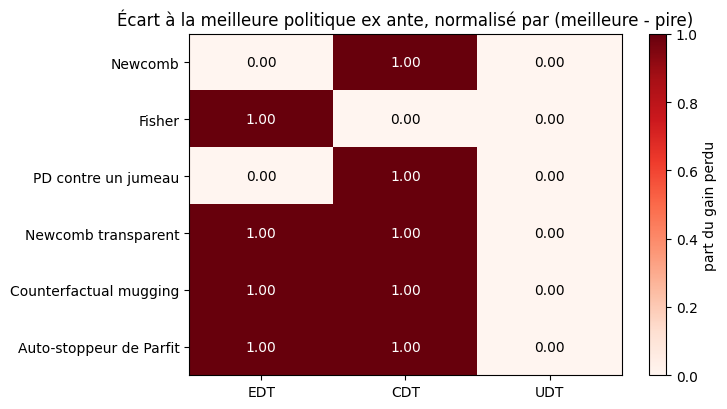

                           EDT    CDT  UDT
Newcomb                  0.000  1.000  0.0
Fisher                   1.000  0.000  0.0
PD contre un jumeau      0.000  1.000  0.0
Newcomb transparent      0.999  0.999  0.0
Counterfactual mugging   1.000  1.000  0.0
Auto-stoppeur de Parfit  1.000  1.000  0.0


In [12]:
matrice = pd.DataFrame(ecarts).T[["EDT", "CDT", "UDT"]]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
im = ax.imshow(matrice.values, cmap="Reds", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(3), matrice.columns)
ax.set_yticks(range(len(matrice)), matrice.index)
for i in range(matrice.shape[0]):
    for j in range(matrice.shape[1]):
        ax.text(j, i, f"{matrice.values[i, j]:.2f}", ha="center", va="center",
                color="white" if matrice.values[i, j] > 0.5 else "black")
fig.colorbar(im, ax=ax, label="part du gain perdu")
ax.set_title("Écart à la meilleure politique ex ante, normalisé par (meilleure - pire)")
plt.tight_layout()
plt.show()
print(matrice.round(3).to_string())

### Lecture du résultat

Chaque case rapporte la perte d'une théorie à l'écart entre la meilleure et la pire politique du problème : $0$ signifie « politique optimale », $1$ « pire politique possible ». L'échelle rend comparables des problèmes dont l'écart entre meilleure et pire politique va de $1$ (Fisher) à $4\,850$ (mugging).

- La colonne CDT vaut $1$ partout sauf sur Fisher. La colonne EDT vaut $1$ sur Fisher, le mugging et Parfit, et $0.999$ sur le Newcomb transparent.
- Quand une théorie se trompe ici, elle ne se trompe pas un peu : elle choisit la pire politique disponible. Le $0.999$ du Newcomb transparent vient de ce qu'il existe, parmi ses quatre politiques, une politique à peine pire que « deux boîtes partout » : prendre deux boîtes quand la boîte est pleine et une seule quand elle est vide.
- La colonne UDT est nulle par construction, comme expliqué ci-dessus.

In [13]:
lignes = []
for pb in PROBLEMES:
    pol_udt = udt(pb)
    for o in pb.observations:
        if o == "vide":
            continue   # observation hors trajectoire de la politique UDT
        a_udt = pol_udt[o]
        ex_post = cdt(pb, o)   # l'état qui compte est fixé une fois o observé
        meilleur = max(ex_post, key=ex_post.get)
        if meilleur != a_udt:
            lignes.append({"problème": pb.nom, "observation": o, "action UDT": a_udt,
                           "meilleure action à monde fixé": meilleur,
                           "coût ex post": ex_post[meilleur] - ex_post[a_udt]})
cout = pd.DataFrame(lignes)
print(cout.to_string(index=False))
mugging = PROBLEMES[4]
engagement = {a: mugging.valeur({"pile": a}) for a in mugging.actions}
print(f"\nMugging, avant le lancer de la pièce : s'engager à payer vaut {engagement['payer']:.0f}, "
      f"à refuser {engagement['refuser']:.0f}")
assert cout["coût ex post"].round(6).tolist() == [1.0, 1.5, 1.0, 100.0, 1.0]
assert "Fisher" not in cout["problème"].tolist()
assert engagement["payer"] > engagement["refuser"]

               problème observation action UDT meilleure action à monde fixé  coût ex post
                Newcomb           -    1 boîte                      2 boîtes           1.0
    PD contre un jumeau           -          C                             D           1.5
    Newcomb transparent      pleine    1 boîte                      2 boîtes           1.0
 Counterfactual mugging        pile      payer                       refuser         100.0
Auto-stoppeur de Parfit       ville      payer                       refuser           1.0

Mugging, avant le lancer de la pièce : s'engager à payer vaut 4900, à refuser 50


### Lecture du résultat

UDT n'est pas gratuit. Une fois l'observation faite et l'état caché fixé, son action est **localement** moins bonne dans cinq des six problèmes. Le coût va d'un millier de dollars laissé sur la table dans les deux Newcomb à $100$ payés pour rien après pile. Contre le jumeau, la défection rapporterait $T - R = 2$ s'il coopère et $P - S = 1$ s'il fait défection, soit $1.5$ sous une crédence de moitié-moitié. Enfin, l'auto-stoppeur paie $1$ au conducteur alors qu'il est déjà sauvé. Fisher n'apparaît pas : UDT y fume, comme CDT, et ne paie rien.

Chacune de ces pertes est le prix d'une **cohérence dans le temps** : l'agent exécute la politique qu'il aurait voulu adopter avant de savoir.

La dernière ligne montre pourquoi même un agent CDT devrait trouver cela raisonnable. Avant le lancer, s'engager à payer vaut $4\,900$ et s'engager à refuser $50$ : un agent CDT capable de se lier les mains **avant** la pièce choisirait de payer. CDT recommande donc de devenir autre chose que CDT dès qu'il en a l'occasion. C'est ce défaut de stabilité réflexive qui a motivé UDT.

### Exercice 2 — Le chantage XOR (Yudkowsky et Soares 2017)

Une rumeur dit que votre maison est infestée de termites, ce qui coûterait $1\,000\,000$ de dollars. Vous ignorez si elle est vraie ; a priori, la probabilité est $\rho = 0.01$. Un prédicteur honnête, qui sait la vérité, vous envoie une lettre **si et seulement si exactement une** des deux propositions suivantes est vraie : (i) la rumeur est fausse **et** vous paierez $1\,000$ dollars en recevant la lettre ; (ii) la rumeur est vraie **et** vous ne paierez pas.

- **Étape 1** : coder ce problème comme une instance de `Probleme` (aléa = termites ou non, observation = « lettre », variable cachée = la lettre est-elle envoyée, avec le bruit `EPS` du prédicteur).
- **Étape 2** : calculer les politiques d'EDT, de CDT et d'UDT et leurs valeurs.
- **Étape 3** : expliquer le verdict d'EDT. Le paiement change-t-il quelque chose aux termites ? Qu'est-ce qu'il change à la probabilité d'avoir reçu la lettre ?

*Indice* : on attend qu'EDT paie et que CDT et UDT refusent. Ce problème sépare UDT d'EDT dans le sens inverse de Fisher : ici, la corrélation passe par le prédicteur, mais payer ne modifie que **la lettre**, pas l'état qui coûte cher.

In [14]:
# Exercice 2 : chantage XOR dans le cadre générique.
# TODO étudiant : définir aleas, type_prior, cache, observe et gain,
# puis appeler politique_de(edt, ...), politique_de(cdt, ...) et udt(...).

RHO = 0.01
chantage_xor = None  # TODO étudiant : instance de Probleme

print("Exercice 2 à compléter : chantage XOR (EDT paie, CDT et UDT refusent).")

Exercice 2 à compléter : chantage XOR (EDT paie, CDT et UDT refusent).


## 5. 2TDT-1CDT : quand une minorité CDT profite de la coopération UDT

La section 4 donne l'avantage à UDT problème par problème. Wei Dai (2023) retourne l'argument avec son quatrième problème ouvert :

> *« If there's a population of mostly TDT/UDT agents and few CDT agents (and nobody knows who the CDT agents are) and they're randomly paired up to play one-shot PD, then the CDT agents do better. What does this imply? »*

Autrement dit : dans une population majoritairement UDT, appariée au hasard pour un dilemme du prisonnier à un coup, les rares agents CDT gagnent davantage que les agents UDT, tant que personne ne sait qui ils sont.

**Modèle.** Une fraction $f$ de la population est CDT, le reste UDT. Les gains sont $(T, R, P, S) = (5, 3, 1, 0)$ : tentation, récompense, punition, dupe.

- Un agent CDT fait toujours défection : c'est sa réponse dominante quand l'action de l'autre est fixée.
- Les agents UDT choisissent une politique commune. Entre eux, ils coopèrent et gagnent $R$, car ils calculent la même politique.
- **Extension du notebook, absente de l'énoncé de Dai** : un agent UDT reconnaît un adversaire CDT avec une probabilité $q$, et fait alors défection. L'énoncé de Dai correspond à $q = 0$.

Tant que les UDT coopèrent par défaut, les gains moyens sont

$$\pi_{\text{UDT}}(f) = (1-f)\,R + f\,\big(qP + (1-q)S\big), \qquad \pi_{\text{CDT}}(f) = (1-f)\,\big(qP + (1-q)T\big) + f\,P.$$

Trois seuils s'en déduisent :

- **Invasion** : un CDT rare ($f \to 0$) gagne plus qu'un UDT ssi $qP + (1-q)T > R$, c'est-à-dire ssi $q < q^* = \dfrac{T-R}{T-P}$.
- **Bascule d'UDT** : coopérer par défaut ne vaut plus que la défection systématique (gain $P$) quand $\pi_{\text{UDT}}(f) < P$, c'est-à-dire au-delà de $f_{\text{bascule}} = \dfrac{R-P}{R - qP - (1-q)S}$. Au-delà, tout le monde fait défection et gagne $P$.
- **Point intérieur** : les deux gains s'égalisent en $f^* = \dfrac{a}{a+b}$, avec $a = R - qP - (1-q)T$ et $b = (1-q)(P-S)$. Il n'existe que si $a > 0$, c'est-à-dire si $q > q^*$.

In [15]:
T2, R2, P2, S2 = (Fr(x) for x in (5, 3, 1, 0))


def gains_2tdt(f, q, T=T2, R=R2, P=P2, S=S2):
    # gains moyens (UDT, CDT) quand les UDT coopèrent par défaut
    return ((1 - f) * R + f * (q * P + (1 - q) * S),
            (1 - f) * (q * P + (1 - q) * T) + f * P)


def seuils_2tdt(q, T=T2, R=R2, P=P2, S=S2):
    q_star = (T - R) / (T - P)
    f_bascule = (R - P) / (R - q * P - (1 - q) * S)
    a, b = R - q * P - (1 - q) * T, (1 - q) * (P - S)
    f_star = a / (a + b) if a > 0 else None
    return q_star, f_bascule, f_star


Q_STAR = seuils_2tdt(Fr(0))[0]
lignes = []
for q in (Fr(0), Fr(1, 4), Fr(1, 2), Fr(3, 5), Fr(3, 4), Fr(9, 10)):
    _, f_b, f_s = seuils_2tdt(q)
    u0, c0 = gains_2tdt(Fr(0), q)
    lignes.append({"q": str(q), "UDT (f -> 0)": str(u0), "CDT (f -> 0)": str(c0),
                   "CDT rare envahit": c0 > u0, "f_bascule": f"{str(f_b)} = {float(f_b):.3f}",
                   "f*": "-" if f_s is None else f"{str(f_s)} = {float(f_s):.3f}"})
print(f"q* = (T - R) / (T - P) = {Q_STAR}")
print(pd.DataFrame(lignes).to_string(index=False))

assert Q_STAR == Fr(1, 2)
assert seuils_2tdt(Fr(0))[1] == Fr(2, 3) and seuils_2tdt(Fr(3, 4))[1] == Fr(8, 9)
assert [seuils_2tdt(q)[2] for q in (Fr(3, 5), Fr(3, 4), Fr(9, 10))] == [Fr(1, 2), Fr(4, 5), Fr(16, 17)]
assert all((gains_2tdt(Fr(0), q)[1] > gains_2tdt(Fr(0), q)[0]) == (q < Q_STAR)
           for q in (Fr(0), Fr(1, 4), Fr(1, 2), Fr(3, 5), Fr(3, 4), Fr(9, 10)))
for q in (Fr(3, 5), Fr(3, 4), Fr(9, 10)):
    _, f_b, f_s = seuils_2tdt(q)
    u, c = gains_2tdt(f_s, q)
    assert u == c and f_s < f_b

q* = (T - R) / (T - P) = 1/2
   q UDT (f -> 0) CDT (f -> 0)  CDT rare envahit     f_bascule            f*
   0            3            5              True   2/3 = 0.667             -
 1/4            3            4              True  8/11 = 0.727             -
 1/2            3            3             False   4/5 = 0.800             -
 3/5            3         13/5             False   5/6 = 0.833   1/2 = 0.500
 3/4            3            2             False   8/9 = 0.889   4/5 = 0.800
9/10            3          7/5             False 20/21 = 0.952 16/17 = 0.941


### Lecture du résultat

- **Le puzzle de Dai est exact** : à $q = 0$, un CDT rare gagne $T = 5$ contre $R = 3$ pour un UDT. Dans une population qui coopère, faire défection sans être reconnu rapporte la tentation à chaque rencontre.
- **Il suffit d'une détection partielle pour le renverser** : dès que $q > q^* = 1/2$, le CDT rare gagne moins que $3$ ($2$ à $q = 3/4$, $1.4$ à $q = 9/10$). Le seuil ne dépend que de $T$, $R$ et $P$, pas de $S$.
- **La coopération UDT résiste jusqu'à une fraction élevée** : $f_{\text{bascule}} = 2/3$ à $q = 0$, $8/9$ à $q = 3/4$. Avant ce seuil, coopérer par défaut rapporte plus que la défection systématique, même en se faisant exploiter par les CDT non détectés.
- **Au-delà de $q^*$, deux régimes coexistent** : sous $f^*$ ($1/2$, $4/5$ puis $16/17$ selon $q$), les UDT gagnent plus et les CDT reculent ; au-dessus, les CDT gagnent plus. Le point $f^*$ reste toujours sous $f_{\text{bascule}}$, ce qui laisse une bande où les CDT progressent encore.

La colonne $q = 1/2$ est le cas limite : un CDT rare gagne exactement $R$, ni plus ni moins qu'un UDT.

### Vérification par simulation d'agents

Les formules supposent une population infinie et des appariements indépendants. La cellule suivante simule une population finie de $2\,000$ agents, dont $10\,\%$ de CDT. À chaque tour, les agents sont appariés au hasard ; un agent UDT face à un CDT le reconnaît avec la probabilité $q$. Le gain moyen de chaque type est comparé à la forme fermée, avec une erreur-type calculée sur les rencontres.

Dans une population finie, un agent UDT rencontre un CDT avec la probabilité $fN/(N-1)$ et non $f$ exactement. L'écart est de l'ordre de $5 \cdot 10^{-5}$ : il reste bien en dessous de l'erreur-type.

In [16]:
def simule_2tdt(n_agents, f, q, tours, rng):
    n_cdt = int(round(f * n_agents))
    est_cdt = np.zeros(n_agents, dtype=bool)
    est_cdt[:n_cdt] = True
    gains_udt, gains_cdt = [], []
    matrice = {("C", "C"): 3, ("C", "D"): 0, ("D", "C"): 5, ("D", "D"): 1}
    for _ in range(tours):
        ordre = rng.permutation(n_agents)
        x, y = ordre[::2], ordre[1::2]
        detecte_x = rng.random(len(x)) < q
        detecte_y = rng.random(len(y)) < q
        # un UDT coopère sauf s'il reconnaît un CDT ; un CDT fait toujours défection
        act_x = np.where(est_cdt[x] | (est_cdt[y] & detecte_x), "D", "C")
        act_y = np.where(est_cdt[y] | (est_cdt[x] & detecte_y), "D", "C")
        gx = np.array([matrice[(a, b)] for a, b in zip(act_x, act_y)])
        gy = np.array([matrice[(b, a)] for a, b in zip(act_x, act_y)])
        for idx, g in ((x, gx), (y, gy)):
            gains_cdt.append(g[est_cdt[idx]])
            gains_udt.append(g[~est_cdt[idx]])
    return np.concatenate(gains_udt), np.concatenate(gains_cdt)


rng = np.random.default_rng(SEED)
N_POP, F_CDT, TOURS = 2_000, 0.1, 150
lignes = []
t0 = time.perf_counter()
for q in (0.0, 0.75):
    g_udt, g_cdt = simule_2tdt(N_POP, F_CDT, q, TOURS, rng)
    th_udt, th_cdt = (float(v) for v in gains_2tdt(Fr(1, 10), Fr(q).limit_denominator(100)))
    for nom, g, th in (("UDT", g_udt, th_udt), ("CDT", g_cdt, th_cdt)):
        se = g.std(ddof=1) / np.sqrt(len(g))
        lignes.append({"q": q, "type": nom, "rencontres": len(g), "gain simulé": round(g.mean(), 4),
                       "forme fermée": round(th, 4), "erreur-type": round(se, 4),
                       "écart / erreur-type": round((g.mean() - th) / se, 2)})
        assert abs(g.mean() - th) < 3 * se
simu = pd.DataFrame(lignes)
print(simu.to_string(index=False))
print(f"({time.perf_counter() - t0:.1f} s)")

   q type  rencontres  gain simulé  forme fermée  erreur-type  écart / erreur-type
0.00  UDT      270000       2.7000         2.700       0.0017                 0.00
0.00  CDT       30000       4.6000         4.600       0.0069                 0.00
0.75  UDT      270000       2.7752         2.775       0.0013                 0.17
0.75  CDT       30000       1.8891         1.900       0.0096                -1.14
(0.4 s)


### Lecture du résultat

Les quatre moyennes simulées tombent à moins de trois erreurs-types de la forme fermée. Avec $10\,\%$ de CDT :

- à $q = 0$, les CDT gagnent $0.9 \times 5 + 0.1 \times 1 = 4.6$ contre $0.9 \times 3 = 2.7$ pour les UDT : l'exploitation de la majorité coopérative est nette ;
- à $q = 0.75$, les CDT tombent à $0.9 \times (0.75 + 0.25 \times 5) + 0.1 = 1.9$, sous les $2.775$ des UDT.

L'erreur-type des CDT est quatre fois (à $q = 0$) puis sept fois (à $q = 0.75$) plus grande que celle des UDT. Ils sont neuf fois moins nombreux, ce qui la multiplie déjà par trois, et leurs gains varient davantage, de $1$ à $5$.

### Dynamique du réplicateur : qui envahit qui ?

Si les stratégies se reproduisent en proportion de leur gain, la fraction de CDT suit la dynamique du réplicateur

$$\dot f = f(1-f)\,\big(\pi_{\text{CDT}}(f) - \pi_{\text{UDT}}(f)\big) = f(1-f)\,\big(f\,b - (1-f)\,a\big).$$

Au-delà de $f_{\text{bascule}}$, les UDT cessent de coopérer et tout le monde gagne $P$ : la dynamique s'arrête. La figure de gauche trace le diagramme des phases en $(q, f)$, celle de droite des trajectoires à $q = 0.25$ et à $q = 0.75$, intégrées par la méthode d'Euler.

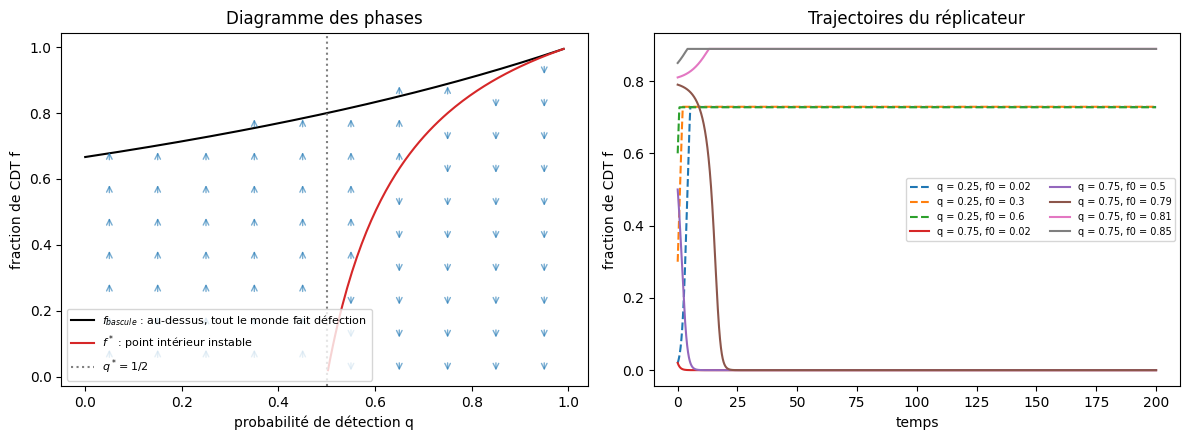

q = 0.25, f0 = 0.02    0.7282
q = 0.25, f0 = 0.3     0.7288
q = 0.25, f0 = 0.6     0.7274
q = 0.75, f0 = 0.02    0.0000
q = 0.75, f0 = 0.5     0.0000
q = 0.75, f0 = 0.79    0.0000
q = 0.75, f0 = 0.81    0.8889
q = 0.75, f0 = 0.85    0.8890


In [17]:
def derive_f(f, q, T=5, R=3, P=1, S=0):
    f_b = (R - P) / (R - q * P - (1 - q) * S)
    if f >= f_b:
        return 0.0   # tout le monde fait défection et gagne P
    a, b = R - q * P - (1 - q) * T, (1 - q) * (P - S)
    return f * (1 - f) * (f * b - (1 - f) * a)


def trajectoire(f0, q, dt=0.01, pas=20_000):
    f, chemin = f0, [f0]
    for _ in range(pas):
        f = min(max(f + dt * derive_f(f, q), 0.0), 1.0)
        chemin.append(f)
    return np.array(chemin)


qs = np.linspace(0, 0.99, 200)
f_b_courbe = [float(seuils_2tdt(Fr(q).limit_denominator(1000))[1]) for q in qs]
f_s_courbe = [float(s) if (s := seuils_2tdt(Fr(q).limit_denominator(1000))[2]) is not None else np.nan for q in qs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(qs, f_b_courbe, color="black", label="$f_{bascule}$ : au-dessus, tout le monde fait défection")
ax.plot(qs, f_s_courbe, color="tab:red", label="$f^*$ : point intérieur instable")
ax.axvline(float(Q_STAR), color="grey", ls=":", label="$q^* = 1/2$")
for q in np.linspace(0.05, 0.95, 10):
    for f in np.linspace(0.05, 0.95, 10):
        v = derive_f(f, q)
        if abs(v) > 1e-9:
            ax.annotate("", xy=(q, f + 0.04 * np.sign(v)), xytext=(q, f),
                        arrowprops=dict(arrowstyle="->", color="tab:blue", alpha=0.6))
ax.set_xlabel("probabilité de détection q")
ax.set_ylabel("fraction de CDT f")
ax.set_title("Diagramme des phases")
ax.legend(fontsize=8, loc="lower left")

ax = axes[1]
temps = np.arange(20_001) * 0.01
DEPARTS = {0.25: (0.02, 0.3, 0.6), 0.75: (0.02, 0.5, 0.79, 0.81, 0.85)}
finales = {}
for q, style in ((0.25, "--"), (0.75, "-")):
    for f0 in DEPARTS[q]:
        chemin = trajectoire(f0, q)
        finales[(q, f0)] = chemin[-1]
        ax.plot(temps, chemin, style, label=f"q = {q}, f0 = {f0}")
ax.set_xlabel("temps")
ax.set_ylabel("fraction de CDT f")
ax.set_title("Trajectoires du réplicateur")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

print(pd.Series({f"q = {q}, f0 = {f0}": round(v, 4) for (q, f0), v in finales.items()}).to_string())
f_b_025, f_b_075 = (float(seuils_2tdt(q)[1]) for q in (Fr(1, 4), Fr(3, 4)))
assert all(abs(finales[(0.25, f0)] - f_b_025) < 0.005 for f0 in DEPARTS[0.25])
assert finales[(0.75, 0.02)] < 1e-3 and finales[(0.75, 0.5)] < 1e-3 and finales[(0.75, 0.79)] < 1e-3
assert abs(finales[(0.75, 0.81)] - f_b_075) < 0.005 and abs(finales[(0.75, 0.85)] - f_b_075) < 0.005

### Lecture du résultat

- **À $q = 0.25$** (sous $q^*$), les trois trajectoires montent jusqu'à $f_{\text{bascule}} = 8/11 \approx 0.727$, même celle qui part de $2\,\%$ de CDT. La minorité CDT envahit, puis la coopération s'effondre : tout le monde fait défection et gagne $P = 1$, moins que les $R = 3$ de la population UDT de départ. Le gain relatif des CDT détruit le gain absolu de tous.
- **À $q = 0.75$** (au-dessus de $q^*$), le système est **bistable**. Les départs à $f_0 = 0.5$ et $0.79$, sous $f^* = 0.8$, voient les CDT disparaître. Ceux à $0.81$ et $0.85$ montent jusqu'à $f_{\text{bascule}} = 8/9$, où la coopération cesse.
- Sur le diagramme des phases, les flèches montent partout à gauche de $q^*$. À droite, elles descendent sous la courbe rouge et montent entre la courbe rouge et la courbe noire.

**Ce que cela dit du puzzle de Dai.** Trois lectures s'affrontent dans la discussion qui suit son billet :

- **cousin_it** : n'importe quel petit groupe qui maximise son propre score moyen bat un grand groupe dans ce tournoi. Les UDT seraient handicapés par le fait de se soucier de leur groupe, non par leur théorie de la décision.
- **Wei Dai** répond que la situation n'est pas symétrique. Avec deux CDT et un UDT, l'UDT ne fait pas mieux que les CDT ; le puzzle tient donc bien à la théorie de la décision, pas seulement à la taille des groupes.
- **Daniel Kokotajlo** y voit un cas particulier d'un phénomène général : *« it's game-theoretically great to be in a position where people think they are correlated/entangled with you when actually you know they aren't »*. Il est avantageux d'être cru corrélé aux autres quand on sait ne pas l'être.

La simulation donne raison à la troisième lecture sous une forme mesurable. L'avantage CDT n'existe que tant que la corrélation supposée n'est pas vérifiée ($q < q^*$). Dès que les UDT reconnaissent assez souvent qui calcule la même politique qu'eux, la corrélation redevient réelle et la minorité CDT disparaît, sauf si elle part déjà d'une fraction supérieure à $f^*$.

### Exercice 3 — Un dilemme où coopérer rapporte davantage

Reprendre l'analyse avec les gains $(T, R, P, S) = (7, 5, 1, 0)$ : la tentation reste à $T - R = 2$ au-dessus de la récompense, mais la coopération rapporte maintenant $R - P = 4$ de plus que la défection mutuelle, contre $2$ auparavant.

- **Étape 1** : calculer $q^*$ en fractions exactes avec `seuils_2tdt` (on doit trouver $1/3$) et $f_{\text{bascule}}$ à $q = 0$.
- **Étape 2** : pour $q \in \{0.5, 0.75\}$, calculer $f^*$ et vérifier que $\pi_{\text{UDT}}(f^*) = \pi_{\text{CDT}}(f^*)$.
- **Étape 3** : tracer deux trajectoires du réplicateur à $q = 0.5$, l'une partant sous $f^*$ et l'autre au-dessus. La coopération UDT est-elle plus ou moins robuste qu'avec $(5, 3, 1, 0)$ ? Comparer $q^*$, $f_{\text{bascule}}$ et $f^*$ dans les deux cas.

*Indice* : `gains_2tdt` et `seuils_2tdt` acceptent les gains en arguments nommés ; `derive_f` et `trajectoire` utilisent les gains par défaut et doivent être adaptés.

In [18]:
# Exercice 3 : 2TDT-1CDT avec (T, R, P, S) = (7, 5, 1, 0).
# TODO étudiant : appeler seuils_2tdt(q, T=Fr(7), R=Fr(5), P=Fr(1), S=Fr(0)) pour plusieurs q,
# vérifier l'égalité des gains en f*, puis intégrer deux trajectoires du réplicateur.

seuils_exercice = None  # TODO étudiant : dictionnaire q -> (q*, f_bascule, f*)

print("Exercice 3 à compléter : q*, f_bascule et f* pour les gains (7, 5, 1, 0).")

Exercice 3 à compléter : q*, f_bascule et f* pour les gains (7, 5, 1, 0).


## 6. Inattention rationnelle : quand observer coûte

Toutes les théories précédentes supposent que l'agent connaît parfaitement ce qu'il observe. Sims (2003) retire cette hypothèse : prêter attention a un coût, mesuré par l'**information mutuelle** $I(s; a)$ entre l'état du monde $s$ et l'action $a$. Une action qui ne dépend pas de l'état ($I = 0$) ne coûte rien ; une action qui suit parfaitement l'état coûte l'entropie de l'état.

Mu, Zheng et Trott (2022) reprennent ce cadre pour des agents d'apprentissage par renforcement (RIRL). Chaque acteur cherche

$$\pi^\dagger = \arg\max_\pi\ \mathbb{E}_\pi\big[U(s, a)\big] - \lambda\, I(a; s),$$

où $\lambda$ est, selon leurs termes, *« the utility cost per bit of information »*. Leur terrain d'étude est un problème principal-agent : un manager fixe la rémunération d'un employé sans observer parfaitement sa production.

**Version réduite étudiée ici.** Un manager fixe une prime $a \in \{0, \dots, 4\}$ pour un employé de productivité $s \in \{0, \dots, 4\}$, de loi a priori $(0.30, 0.25, 0.20, 0.15, 0.10)$. L'utilité du manager est $u(a, s) = -(a - s)^2$, multipliée par $1.5$ quand il surpaye ($a > s$).

**Solution.** Matějka et McKay (2015) montrent que la politique optimale a une forme logit pondérée par la loi marginale des actions :

$$p(a \mid s) = \frac{p(a)\, e^{u(a, s)/\lambda}}{\sum_b p(b)\, e^{u(b, s)/\lambda}}, \qquad p(a) = \sum_s p(s)\, p(a \mid s).$$

Ce point fixe se calcule par l'algorithme de **Blahut-Arimoto** (1972), conçu à l'origine pour la fonction taux-distorsion en théorie de l'information. Deux conventions à ne pas confondre : l'exponentielle $e^{u/\lambda}$ mesure l'information en **nats**, alors que Mu et al. comptent en **bits**. Les deux coûts sont liés par $\lambda_{\text{bit}} = \lambda_{\text{nat}} \ln 2$.

**Conditions de premier ordre.** À l'optimum, la quantité $c(a) = \sum_s p(s)\, e^{u(a,s)/\lambda} / Z(s)$ vaut exactement $1$ sur le support de $p(a)$, et au plus $1$ en dehors. Cette vérification ne dépend pas de l'algorithme employé.

In [19]:
S_VALS = np.arange(5)                       # productivité de l'employé
A_VALS = np.arange(5)                       # prime fixée par le manager
PRIOR_S = np.array([0.30, 0.25, 0.20, 0.15, 0.10])
U_RI = -(A_VALS[:, None] - S_VALS[None, :]) ** 2.0
U_RI = np.where(A_VALS[:, None] > S_VALS[None, :], 1.5 * U_RI, U_RI)   # surpayer coûte 1.5 fois plus


def blahut_arimoto(U, prior, lam, iters=20_000, tol=1e-13):
    # point fixe de Matějka-McKay ; lam est un coût par nat
    marge = np.full(U.shape[0], 1.0 / U.shape[0])
    E = np.exp((U - U.max(axis=0, keepdims=True)) / lam)   # stabilisation colonne par colonne
    for it in range(1, iters + 1):
        cond = marge[:, None] * E / (marge @ E)[None, :]
        nouvelle = cond @ prior
        ecart = np.abs(nouvelle - marge).max()
        marge = nouvelle
        if ecart < tol:
            break
    cond = marge[:, None] * E / (marge @ E)[None, :]
    return marge, cond, it


def info_mutuelle(cond, prior, base=2.0):
    marge = cond @ prior
    with np.errstate(divide="ignore", invalid="ignore"):
        t = np.where(cond > 0, cond * np.log(cond / marge[:, None]), 0.0)
    return float((t @ prior).sum() / np.log(base))


def esperance(U, cond, prior):
    return float(((U * cond) @ prior).sum())


def cpo(U, prior, lam, marge):
    E = np.exp((U - U.max(axis=0, keepdims=True)) / lam)
    return (E / (marge @ E)[None, :]) @ prior


H_PRIOR = float(-(PRIOR_S * np.log2(PRIOR_S)).sum())
MEILLEURE_CONSTANTE = (PRIOR_S @ U_RI.T).max()
A_CONSTANTE = int((PRIOR_S @ U_RI.T).argmax())
LAMBDAS = [0.05, 0.3, 0.8, 1.5, 3.0, 6.0]
lignes, SOLUTIONS = [], {}
for lam in LAMBDAS:
    marge, cond, it = blahut_arimoto(U_RI, PRIOR_S, lam)
    SOLUTIONS[lam] = (marge, cond)
    support = np.flatnonzero(marge > 1e-6)
    c = cpo(U_RI, PRIOR_S, lam, marge)
    hors = np.setdiff1d(A_VALS, support)
    lignes.append({"lambda (par nat)": lam, "lambda (par bit)": round(lam * np.log(2), 4),
                   "I(s;a) bits": round(info_mutuelle(cond, PRIOR_S), 4),
                   "E[u]": round(esperance(U_RI, cond, PRIOR_S), 4),
                   "p(a)": np.round(marge, 3).tolist(), "support": support.tolist(),
                   "résidu CPO": float(np.abs(c[support] - 1).max()),
                   "max c(a) hors support": round(float(c[hors].max()), 4) if len(hors) else "-",
                   "itérations": it})
table_ri = pd.DataFrame(lignes)
with pd.option_context("display.width", 200):
    print(table_ri.to_string(index=False))
print(f"\nH(prior) = {H_PRIOR:.4f} bits ; meilleure prime constante : a = {A_CONSTANTE}, E[u] = {MEILLEURE_CONSTANTE:.2f}")

assert [len(s) for s in table_ri["support"]] == [5, 5, 5, 3, 2, 2]
assert table_ri["support"].tolist()[3:] == [[0, 1, 3], [1, 3], [1, 2]]
assert (table_ri["résidu CPO"] < 1e-9).all()
assert all(m == "-" or m <= 1 + 1e-9 for m in table_ri["max c(a) hors support"])
assert abs(table_ri["I(s;a) bits"].iloc[0] - H_PRIOR) < 1e-3
assert table_ri["I(s;a) bits"].is_monotonic_decreasing and table_ri["E[u]"].is_monotonic_decreasing
assert A_CONSTANTE == 1 and abs(MEILLEURE_CONSTANTE + 2.15) < 1e-12

 lambda (par nat)  lambda (par bit)  I(s;a) bits    E[u]                                p(a)         support   résidu CPO max c(a) hors support  itérations
             0.05            0.0347       2.2282 -0.0000         [0.3, 0.25, 0.2, 0.15, 0.1] [0, 1, 2, 3, 4] 1.110223e-16                     -           3
             0.30            0.2079       1.9939 -0.0379 [0.309, 0.248, 0.199, 0.149, 0.095] [0, 1, 2, 3, 4] 4.729550e-14                     -          14
             0.80            0.5545       1.1981 -0.3203   [0.335, 0.25, 0.181, 0.175, 0.06] [0, 1, 2, 3, 4] 5.770939e-13                     -         134
             1.50            1.0397       0.7182 -0.6847     [0.223, 0.483, 0.0, 0.294, 0.0]       [0, 1, 3] 2.033929e-13                 0.985        1502
             3.00            2.0794       0.2828 -1.3288         [0.0, 0.81, 0.0, 0.19, 0.0]          [1, 3] 2.475797e-13                0.9672         760
             6.00            4.1589       0.0275 -2.0116       [

### Lecture du résultat

- **Attention presque gratuite** ($\lambda = 0.05$ par nat) : $I(s; a) = 2.2282$ bits, soit exactement l'entropie de la loi a priori. Le manager connaît la productivité et paye la prime juste.
- **Attention de plus en plus chère** : l'information chute de $1.99$ bits à $\lambda = 0.3$ à $0.72$ bit à $\lambda = 1.5$, puis à $0.03$ bit à $\lambda = 6$.
- **L'ensemble de considération se contracte** : à $\lambda = 1.5$, les primes $2$ et $4$ ont une probabilité nulle et seules $\{0, 1, 3\}$ restent en jeu. À $\lambda = 3$, il ne reste que $\{1, 3\}$. Le manager n'hésite plus entre cinq niveaux, il en choisit deux et ne consacre son attention qu'à les départager. C'est la prédiction distinctive de l'inattention rationnelle, par opposition à un simple bruit logit qui garderait toutes les actions.
- **Les conditions de premier ordre sont vérifiées à moins de $10^{-9}$** sur le support. Hors support, $c(a)$ reste sous $1$ : ajouter une prime écartée ne rapporterait rien. La solution est donc certifiée indépendamment de l'algorithme.
- En pratique, $\lambda = 1.5$ par nat correspond à $1.04$ par bit dans la convention de Mu et al.
- À $\lambda = 6$, l'utilité espérée ($-2.01$) approche déjà celle de la meilleure prime **constante**, $a = 1$, qui rapporte $-2.15$ sans aucune information.

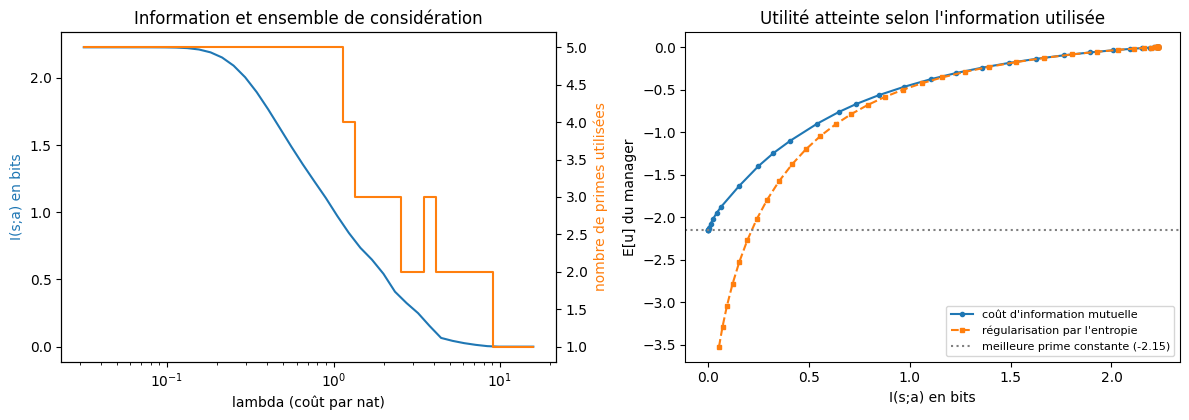

Primes utilisées, par valeur de lambda où l'ensemble change :
 lambda          primes
  0.032 (0, 1, 2, 3, 4)
  1.237    (0, 1, 2, 3)
  1.451       (0, 1, 3)
  2.744          (1, 3)
  3.775       (1, 2, 3)
  4.427          (1, 2)
  9.824            (1,)

E[u] minimale sous coût d'information : -2.1500 (borne -2.15)
E[u] minimale sous régularisation par l'entropie : -3.5254
politique uniforme (limite de l'entropie) : E[u] = -5.3650


In [20]:
def entropie_reguliere(U, lam):
    # régularisation par l'entropie : softmax de référence uniforme, sans marge apprise
    E = np.exp((U - U.max(axis=0, keepdims=True)) / lam)
    return E / E.sum(axis=0, keepdims=True)


grille = np.logspace(-1.5, 1.2, 40)
courbe = []
for lam in grille:
    marge, cond = blahut_arimoto(U_RI, PRIOR_S, lam)[:2]
    ent = entropie_reguliere(U_RI, lam)
    courbe.append({"lambda": lam, "I": info_mutuelle(cond, PRIOR_S), "E[u]": esperance(U_RI, cond, PRIOR_S),
                   "support": int((marge > 1e-6).sum()), "primes": tuple(np.flatnonzero(marge > 1e-6).tolist()),
                   "I entropie": info_mutuelle(ent, PRIOR_S), "E[u] entropie": esperance(U_RI, ent, PRIOR_S),
                   # objectif E[u] - lambda I (en nats) : optimum de Blahut-Arimoto contre politique d'entropie
                   "objectif optimal": esperance(U_RI, cond, PRIOR_S) - lam * info_mutuelle(cond, PRIOR_S, base=np.e),
                   "objectif entropie": esperance(U_RI, ent, PRIOR_S) - lam * info_mutuelle(ent, PRIOR_S, base=np.e)})
courbe = pd.DataFrame(courbe)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
ax = axes[0]
ax.semilogx(courbe["lambda"], courbe["I"], color="tab:blue", label="I(s;a), coût d'information mutuelle")
ax.set_xlabel("lambda (coût par nat)")
ax.set_ylabel("I(s;a) en bits", color="tab:blue")
ax2 = ax.twinx()
ax2.step(courbe["lambda"], courbe["support"], where="mid", color="tab:orange", label="taille du support")
ax2.set_ylabel("nombre de primes utilisées", color="tab:orange")
ax.set_title("Information et ensemble de considération")

ax = axes[1]
ax.plot(courbe["I"], courbe["E[u]"], "o-", ms=3, label="coût d'information mutuelle")
ax.plot(courbe["I entropie"], courbe["E[u] entropie"], "s--", ms=3, label="régularisation par l'entropie")
ax.axhline(MEILLEURE_CONSTANTE, color="grey", ls=":", label=f"meilleure prime constante ({MEILLEURE_CONSTANTE:.2f})")
ax.set_xlabel("I(s;a) en bits")
ax.set_ylabel("E[u] du manager")
ax.set_title("Utilité atteinte selon l'information utilisée")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

transitions = courbe.loc[courbe["primes"] != courbe["primes"].shift(), ["lambda", "primes"]]
print("Primes utilisées, par valeur de lambda où l'ensemble change :")
print(transitions.round(3).to_string(index=False))
print(f"\nE[u] minimale sous coût d'information : {courbe['E[u]'].min():.4f} (borne {MEILLEURE_CONSTANTE:.2f})")
print(f"E[u] minimale sous régularisation par l'entropie : {courbe['E[u] entropie'].min():.4f}")
print(f"politique uniforme (limite de l'entropie) : E[u] = {esperance(U_RI, np.full((5, 5), 0.2), PRIOR_S):.4f}")
assert (courbe["E[u]"] >= MEILLEURE_CONSTANTE - 1e-9).all()
assert courbe["E[u] entropie"].min() < MEILLEURE_CONSTANTE
assert np.all(np.diff(courbe["I"]) <= 1e-9)
assert transitions["primes"].tolist() == [(0, 1, 2, 3, 4), (0, 1, 2, 3), (0, 1, 3), (1, 3), (1, 2, 3), (1, 2), (1,)]
assert (courbe["objectif optimal"] >= courbe["objectif entropie"] - 1e-9).all()

### Lecture du résultat

- **Gauche** : l'information décroît de façon monotone quand $\lambda$ augmente. Le nombre de primes utilisées, lui, **ne décroît pas de façon monotone**. La prime $4$ disparaît la première (vers $\lambda \approx 1.2$ sur cette grille) : elle ne sert qu'à la productivité la plus rare ($10\,\%$) et surpayer coûte cher. La prime $2$ la suit, puis la prime $0$. Vers $\lambda \approx 3.8$, la prime $2$ **revient**, puis la prime $3$ s'efface vers $\lambda \approx 4.4$. Les deux catégories « faible » et « forte » fusionnent alors en un compromis $\{1, 2\}$, avant que la seule prime $1$ ne subsiste au-delà de $\lambda \approx 9.8$.
- **Droite** : sous le coût d'information mutuelle, l'utilité du manager ne descend jamais sous $-2.15$, la valeur de la meilleure prime constante, atteinte exactement quand l'information tombe à zéro. Ce n'est pas un hasard numérique : la politique constante a une information nulle, donc un coût nul, et reste toujours disponible. L'optimum fait donc au moins aussi bien qu'elle.
- **La régularisation par l'entropie viole cette borne.** Elle pousse la politique vers le tirage uniforme des primes, qui ne demande pas plus d'attention qu'une prime fixe ($I = 0$ dans les deux cas) mais rapporte $-5.365$ au lieu de $-2.15$. Sur la grille, son utilité descend jusqu'à $-3.53$. Sur la figure, sa courbe reste sous celle de l'information mutuelle : à information égale, elle rapporte moins. La cellule le confirme sous une forme sans interpolation : à chaque $\lambda$ de la grille, la politique d'entropie évaluée avec le coût d'information mutuelle ne dépasse jamais l'optimum de Blahut-Arimoto.

C'est, sur un problème de cinq états, le constat de la figure 1a de Mu et al. : *« under RIRL, $U_p$ approaches this lower bound as increasing $\lambda$ leads the Principal to trade more profitable W's for ones with smaller demands on attention. In contrast, under entropy regularization, increasing $\lambda$ quickly yields W's that violate the $U_p$ lower bound »*. La différence tient à la marge $p(a)$ : le coût d'information mutuelle autorise l'agent à concentrer ses actions sur quelques primes sans payer, alors que l'entropie pénalise toute concentration.

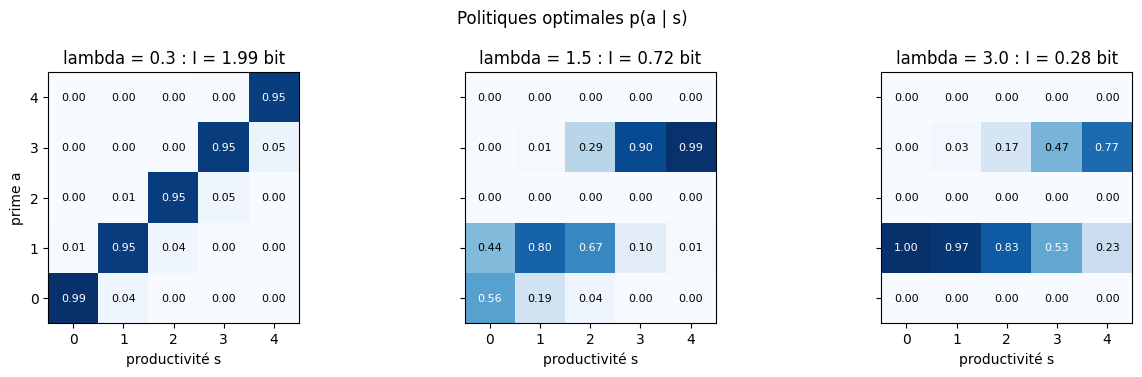

lambda = 0.3: prime la plus probable par productivité = [0, 1, 2, 3, 4]
lambda = 1.5: prime la plus probable par productivité = [0, 1, 1, 3, 3]
lambda = 3.0: prime la plus probable par productivité = [1, 1, 1, 1, 3]


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, lam in zip(axes, (0.3, 1.5, 3.0)):
    marge, cond = SOLUTIONS[lam]
    ax.imshow(cond, cmap="Blues", vmin=0, vmax=1, origin="lower")
    for a in A_VALS:
        for s in S_VALS:
            ax.text(s, a, f"{cond[a, s]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if cond[a, s] > 0.5 else "black")
    ax.set_xticks(S_VALS)
    ax.set_yticks(A_VALS)
    ax.set_xlabel("productivité s")
    ax.set_title(f"lambda = {lam} : I = {info_mutuelle(cond, PRIOR_S):.2f} bit")
axes[0].set_ylabel("prime a")
fig.suptitle("Politiques optimales p(a | s)")
plt.tight_layout()
plt.show()

for lam in (0.3, 1.5, 3.0):
    marge, cond = SOLUTIONS[lam]
    print(f"lambda = {lam}: prime la plus probable par productivité = {cond.argmax(axis=0).tolist()}")
assert SOLUTIONS[3.0][1].argmax(axis=0).tolist() == [1, 1, 1, 1, 3]
assert SOLUTIONS[1.5][1].argmax(axis=0).tolist() == [0, 1, 1, 3, 3]

### Lecture du résultat

- À $\lambda = 0.3$, la diagonale domine : chaque productivité reçoit sa propre prime avec une probabilité d'au moins $0.95$, le reste allant à une prime voisine.
- À $\lambda = 1.5$, les lignes des primes $2$ et $4$ sont vides. Les productivités $3$ et $4$ reçoivent presque toujours la prime $3$ ($0.90$ et $0.99$). La productivité $1$ reçoit surtout la prime $1$ ($0.80$). La productivité $0$ hésite entre $0$ et $1$ ($0.56$ et $0.44$), et la productivité $2$ est payée $1$ deux fois sur trois.
- À $\lambda = 3$, il ne reste que les primes $1$ et $3$, et la probabilité de recevoir $3$ croît avec la productivité : $0.004$, $0.03$, $0.17$, $0.47$ puis $0.77$. Le manager ne pose plus qu'une question binaire, et il y répond mal : un employé de productivité $4$ reçoit encore la prime basse une fois sur quatre.

La prime la plus probable n'est donc plus une fonction nette de la productivité. L'inattention rationnelle ne produit pas une grille grossière appliquée sans erreur, mais une politique bruitée sur un petit nombre de primes.

### Contre-vérification par optimisation directe

Blahut-Arimoto exploite la forme analytique de la solution. Pour s'assurer qu'il n'est pas coincé dans un point fixe sous-optimal, la cellule suivante maximise directement $\mathbb{E}[u] - \lambda I(s; a)$ sur les $25$ probabilités conditionnelles avec `scipy.optimize.minimize` (méthode SLSQP), depuis cinq points de départ tirés dans des lois de Dirichlet. Le coût est compté en nats, comme dans l'algorithme.

In [22]:
def moins_objectif(x, lam):
    c = np.clip(x.reshape(5, 5), 1e-12, None)
    marge = c @ PRIOR_S
    info_nats = float(((c * np.log(c / marge[:, None])) @ PRIOR_S).sum())
    return -(esperance(U_RI, c, PRIOR_S) - lam * info_nats)


contraintes = [{"type": "eq", "fun": (lambda x, j=j: x.reshape(5, 5)[:, j].sum() - 1)} for j in range(5)]
lignes = []
t0 = time.perf_counter()
for lam in (0.3, 1.5, 3.0):
    marge, cond = SOLUTIONS[lam]
    valeur_ba = esperance(U_RI, cond, PRIOR_S) - lam * info_mutuelle(cond, PRIOR_S, base=np.e)
    meilleure = -np.inf
    for graine in range(5):
        x0 = np.random.default_rng(graine).dirichlet(np.ones(5), size=5).T.ravel()
        res = minimize(moins_objectif, x0, args=(lam,), method="SLSQP", bounds=[(0, 1)] * 25,
                       constraints=contraintes, options={"maxiter": 2000, "ftol": 1e-12})
        meilleure = max(meilleure, -res.fun)
    lignes.append({"lambda": lam, "Blahut-Arimoto": round(valeur_ba, 8), "SLSQP (5 départs)": round(meilleure, 8),
                   "écart": valeur_ba - meilleure})
    assert abs(valeur_ba - meilleure) < 1e-7
print(pd.DataFrame(lignes).to_string(index=False))
print(f"({time.perf_counter() - t0:.1f} s)")

 lambda  Blahut-Arimoto  SLSQP (5 départs)        écart
    0.3       -0.452481          -0.452481 2.718698e-10
    1.5       -1.431416          -1.431416 1.494316e-11
    3.0       -1.916933          -1.916933 1.794431e-11
(3.5 s)


### Lecture du résultat

Les deux méthodes s'accordent à moins de $10^{-7}$ sur les trois valeurs de $\lambda$. SLSQP ne trouve aucune politique meilleure que le point fixe de Blahut-Arimoto : ce dernier est bien l'optimum global, ce que la concavité de l'objectif laissait attendre et que les conditions de premier ordre avaient déjà certifié.

**Ce que ce notebook ne reproduit pas.** Mu et al. étudient des acteurs **multiples** (un manager et plusieurs employés, eux-mêmes à rationalité limitée), entraînés par renforcement, avec des politiques récurrentes (LSTM) et une information mutuelle **estimée** par un discriminateur neuronal à partir d'échantillons. Ici, l'état a cinq valeurs, la politique est un tableau $5 \times 5$ et l'information mutuelle se calcule exactement. Cette version réduite isole le mécanisme, contraction de l'ensemble de considération et borne de la politique constante, mais ne dit rien des interactions stratégiques qu'ils observent, comme l'employé qui profite de l'inattention du manager.

### Exercice 4 — Une productivité plutôt élevée

Reprendre l'étude avec une loi a priori décalée vers les productivités élevées : $(0.05, 0.10, 0.15, 0.30, 0.40)$.

- **Étape 1** : calculer la meilleure prime constante et sa valeur (celle vers laquelle tend la politique quand $\lambda \to \infty$).
- **Étape 2** : balayer $\lambda$ et relever les valeurs auxquelles le support de $p(a)$ passe de $5$ à $4$, $3$, $2$ puis $1$ prime. Quelles primes disparaissent en premier ?
- **Étape 3** : vérifier les conditions de premier ordre pour deux valeurs de $\lambda$ avec la fonction `cpo`, et comparer la courbe $I(s; a)$ à celle de la loi symétrique. Pourquoi la loi décalée conduit-elle à garder des primes plus élevées ?

*Indice* : `blahut_arimoto(U_RI, prior, lam)` accepte n'importe quelle loi a priori ; le seuil $10^{-6}$ sur $p(a)$ sert à définir le support.

In [23]:
# Exercice 4 : inattention rationnelle avec une loi a priori décalée.
# TODO étudiant : calculer la meilleure prime constante, balayer lambda, relever les paliers du support.

PRIOR_DECALE = np.array([0.05, 0.10, 0.15, 0.30, 0.40])
paliers_support = None  # TODO étudiant : dictionnaire taille du support -> premier lambda observé

print("Exercice 4 à compléter : paliers du support pour une loi a priori décalée.")

Exercice 4 à compléter : paliers du support pour une loi a priori décalée.


## 7. Frontière de l'implémentation : ce que ce notebook ne résout pas

Wei Dai termine son billet par une liste de sept problèmes, dont il écrit : *« As far as I know nobody has found definitive solutions to any of these problems yet, and most are wide open. »* Le tableau situe chacun d'eux par rapport à ce que les sections précédentes calculent.

| n° (Dai 2023) | Problème | Ce que le notebook en touche | Ce qui reste hors de portée |
|---|---|---|---|
| 1 | Valeurs indexicales | rien : le gain dépend de l'aléa, de la variable cachée et de l'action, jamais de la question « quelle copie suis-je ? » | la signature de la fonction d'utilité d'UDT exclut ces valeurs, alors que les humains semblent en avoir |
| 2 | Course aux engagements en temps logique | l'engagement avant le lancer de la pièce (section 4) | cet engagement a lieu en temps physique ; s'engager avant d'avoir *calculé* une conséquence n'a pas de formalisation qui fonctionne |
| 3 | Raisonnement anthropique | rien | UDT le ramène à des préférences, sans dire d'où elles viennent |
| 4 | 2TDT-1CDT | section 5 : seuils exacts, simulation d'agents, dynamique | le calcul dit **quand** une minorité CDT profite, pas ce qu'UDT doit en conclure |
| 5 | Théorie des jeux sous UDT | jumeau et 2TDT, avec des politiques fixées | aucun concept d'équilibre entre agents UDT de codes sources différents |
| 6 | Accès à son propre code source | le prédicteur reçoit directement la politique | un humain ne lit pas son propre algorithme : comment évalue-t-il une corrélation logique avec un autre agent ? |
| 7 | Conditionnels et contrefactuels logiques | la variable cachée $h$ **dépend explicitement** de $\pi$ dans le cadre de la section 4 | c'est cette dépendance qu'une théorie logique doit **dériver** quand l'énoncé ne la donne pas |

Trois choix de modélisation propres au notebook limitent aussi la portée des résultats :

- **Le prédicteur est un oracle probabiliste sur des politiques.** Il reçoit $\pi$ et se trompe avec une probabilité $\varepsilon = 0.01$. La difficulté du problème 7, savoir *ce que* le prédicteur calcule et en quoi le choix de l'agent l'affecte, est donc tranchée par l'énoncé avant qu'aucune théorie ne s'applique.
- **La métrique de la section 4 est le critère d'UDT.** Le manque à gagner normalisé mesure l'écart à la meilleure politique ex ante : il localise les désaccords, il ne les arbitre pas.
- **La reconnaissance $q$ de la section 5 est une extension.** L'énoncé de Dai correspond à $q = 0$. La bistabilité observée à $q = 3/4$ dépend de cette hypothèse, et du fait que tous les UDT partagent une même politique.

Côté inattention rationnelle, la section 6 résout exactement un problème à un seul décideur et cinq états. L'apprentissage par renforcement multi-agent de Mu, Zheng et Trott, avec une information mutuelle estimée par un réseau de neurones, n'est pas reproduit.

## 8. Conclusion

Les sections précédentes posent une seule question à chaque théorie : **qu'est-ce qui compte comme conséquence de mon choix ?** Les réponses se distinguent par leurs chiffres.

1. **Newcomb.** Le seuil d'EDT est $p^* = 1001/2000$, à peine au-dessus du hasard. Au-delà, le groupe qui prend une boîte est plus riche, et pourtant chacun de ses membres aurait gagné $1\,000$ dollars de plus en prenant les deux. Les deux constats portent sur le même tirage.
2. **Fisher.** EDT arrête ($8$ contre $5$), CDT fume ($7$ contre $6$). Les données seules ne départagent pas ces deux verdicts : `dowhy` ne retrouve $P(\text{cancer} \mid \mathrm{do}(S)) \approx 0.4$ que si on lui fournit le bon graphe causal. La défense du chatouillement réconcilie EDT et CDT, à condition que l'agent observe tout ce par quoi le gène agit sur son choix.
3. **CCDT.** Avec des conséquences assez fines pour contenir l'acte, elle redonne EDT à la fraction près, comme l'établit Mohajeri. Avec des conséquences plus grossières, elle ne dit plus rien.
4. **UDT.** Sur six problèmes traités par un seul cadre, UDT suit la dépendance du monde à la politique et ignore la cause commune. Il paie ce choix ex post dans cinq problèmes sur six. Un agent CDT capable de s'engager avant le lancer de la pièce choisirait lui-même la politique d'UDT.
5. **2TDT-1CDT.** Si les UDT ne reconnaissent pas les CDT ($q = 0$), une minorité CDT gagne davantage et croît jusqu'au seuil $f = 2/3$, où coopérer par défaut ne rapporte plus que la défection. Au-dessus de $q^* = 1/2$, une petite minorité CDT disparaît, mais une part de CDT déjà supérieure à $f^*$ monte jusqu'au seuil de bascule : à $q = 3/4$, $f^* = 4/5$ et la bascule a lieu à $8/9$.
6. **Inattention rationnelle.** Quand l'information coûte, la politique optimale utilise moins de primes, selon un ordre qui n'est pas monotone, et son utilité ne descend jamais sous celle de la meilleure prime constante. La régularisation par l'entropie, souvent employée à sa place, viole cette borne.

Aucune de ces théories ne l'emporte sur tous les critères à la fois. EDT et CDT échouent chacune sur des problèmes que l'autre résout. UDT les réconcilie sur ces problèmes, mais au prix de pertes ex post, d'une vulnérabilité mesurable dans 2TDT-1CDT et des sept problèmes ouverts de la section 7. Le constat de Dai tient : la théorie de la décision est plus difficile qu'on ne le pensait avant UDT.

**Pour aller plus loin** : le notebook [04e](GameTheory-04e-Reflective-Oracles.ipynb) formalise, avec les oracles réflexifs, un agent qui raisonne sur un autre agent capable de le modéliser, c'est-à-dire la situation du problème 6.

## Références

**Théories de la décision**

- Nozick, R. (1969). Newcomb's problem and two principles of choice. In N. Rescher (dir.), *Essays in Honor of Carl G. Hempel*, Reidel, 114-146.
- Lewis, D. (1981). Causal decision theory. *Australasian Journal of Philosophy*, 59(1), 5-30.
- Lewis, D. (1981). Why ain'cha rich? *Noûs*, 15(3), 377-380.
- Eells, E. (1982). *Rational Decision and Causality*. Cambridge University Press.
- Edgington, D. (2011). Conditionals, causation, and decision. *Analytic Philosophy*, 52(2), 75-87.
- Mohajeri, M. (2023). Conditional causal decision theory reduces to evidential decision theory. *Analytic Philosophy*, doi:10.1111/phib.12298.
- Dai, W. (2009). Towards a new decision theory. *LessWrong*, 13 août 2009.
- Dai, W. (2023). UDT shows that decision theory is more puzzling than ever. *AI Alignment Forum*, 13 septembre 2023.
- Nesov, V. (2009). Counterfactual mugging. *LessWrong*, 19 mars 2009.
- Parfit, D. (1984). *Reasons and Persons*. Oxford University Press.
- Yudkowsky, E., Soares, N. (2017). Functional decision theory: a new theory of instrumental rationality. arXiv:1710.05060.

**Causalité**

- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference*, 2e édition. Cambridge University Press.
- Blöbaum, P., Götz, P., Budhathoki, K., Mastakouri, A. A., Janzing, D. (2022). DoWhy-GCM: an extension of DoWhy for causal inference in graphical causal models. arXiv:2206.06821.

**Inattention rationnelle**

- Sims, C. A. (2003). Implications of rational inattention. *Journal of Monetary Economics*, 50(3), 665-690.
- Matějka, F., McKay, A. (2015). Rational inattention to discrete choices: a new foundation for the multinomial logit model. *American Economic Review*, 105(1), 272-298.
- Mu, T., Zheng, S., Trott, A. (2022). Modeling bounded rationality in multi-agent simulations using rationally inattentive reinforcement learning. arXiv:2202.01691.
- Arimoto, S. (1972). An algorithm for computing the capacity of arbitrary discrete memoryless channels. *IEEE Transactions on Information Theory*, 18(1), 14-20.
- Blahut, R. E. (1972). Computation of channel capacity and rate-distortion functions. *IEEE Transactions on Information Theory*, 18(4), 460-473.

Les trois sources primaires citées en tête du notebook sont archivées dans la bibliographie partagée (chemins indiqués dans l'introduction) ; les PDF ne sont pas versionnés.

**Retour** : [<< GT-04e Oracles réflexifs](GameTheory-04e-Reflective-Oracles.ipynb) | [Index GameTheory](README.md)